In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import warnings
pd.set_option("display.max_columns", 500)
warnings.filterwarnings('ignore')

EVENTS_DIR = Path("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched")
HOURLY_DIR = Path("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data")
SPIKES_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/all_spikes_dataset_new.csv"
VAULTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_list.csv"
BORROWERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_borrowers_share.csv"
SUPPLIERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_suppliers_share.csv"


CRYPTO_MARKETS = [
    'eth_wbtc_usdc', 'base_wbtc_usdt', 'eth_cbbtc_usdc',
    'eth_wbtc_usdt', "eth_wsteth_usdt", 'eth_weth_usdt', 'eth_cbbtc_usdt',
]
PT_MARKETS = [
    "eth_PT-RLP-4SEP2025_usdc", "eth_PT-USD0++-27MAR2025_usdc",
    "eth_PT-USD0++-31OCT2024_usdc", "eth_PT-USDe-25SEP2025_dai",
    "eth_PT-USDe-25SEP2025_usdc", "eth_PT-USDe-25SEP2025_usdt",
    "eth_PT-USDe-27MAR2025_dai", "eth_PT-USDe-27NOV2025_usds",
    "eth_PT-USDe-31JUL2025_dai", "eth_PT-USR-29MAY2025_usdc",
    "eth_PT-csUSDL-31JUL2025_usdc", "eth_PT-lvlUSD-29MAY2025_usdc",
    "eth_PT-mHYPER-20NOV2025_usdc", "eth_PT-reUSD-18DEC2025_usdc",
    "eth_PT-reUSD-25JUN2026_usdc", "eth_PT-sNUSD-5MAR2026_usdc",
    "eth_PT-sdeUSD-1753142406_usdc", "eth_PT-slvlUSD-25SEP2025_usdc",
    "eth_PT-slvlUSD-29MAY2025_usdc", "eth_PT-stcUSD-23JUL2026_usdc",
    "eth_PT-stcUSD-29JAN2026_usdc", "eth_PT-syrupUSDC-28AUG2025_usdc",
    "eth_PT-syrupUSDC-30OCT2025_usdc", "eth_PT-wstUSR-25SEP2025_usdc",
    "eth_PT-wstUSR-27MAR2025_usdc", "eth_PT-wstUSR-27MAR2025_usr",
    "PT-reUSD-25JUN2026_usdc", "PT-siUSD-26MAR2026_usdc",
]
YB_TOKENS = [
    'eth_usr_usdc', 'eth_wsteth_usdc', 'eth_rlp_usdc',
    'eth_usd0++_usdc', 'eth_fxsave_usdc', 'eth_mapollo_usdc',
    'eth_wsrusd_usdc', 'eth_syrupusdc_pyusd', 'eth_susde_pyusd',
    'eth_stcusd_usdc', 'eth_usde_dai', 'eth_mhyper_usdc', 'eth_syrupusdc_usdc',
    'eth_wstusr_usdc','eth_slvlusd_usdc','eth_csusdl_usdc', 'eth_mF-ONE_usdc', 'eth_reusd_usdc',
    'eth_siusd_usdc', 'eth_sdeusd_usdc'
]




INTERESTING_MARKETS = YB_TOKENS



### **Create dataset**

In [4]:
def load_spikes():
    df = pd.read_csv(SPIKES_PATH)
    df['spike_trigger_datetime'] = pd.to_datetime(df['spike_trigger_datetime'])
    df['spike_recovery_datetime'] = pd.to_datetime(df['spike_recovery_datetime'])
    print(df.isna().sum())
    df = df.dropna(subset=['spike_recovery_datetime'])
    df = df[df['market_name'].isin(INTERESTING_MARKETS)]
    return df

def load_all_events():
    dfs = []
    for market in INTERESTING_MARKETS:
        f = EVENTS_DIR / f"{market}.csv"
        if f.exists():
            df = pd.read_csv(f)
            df['market'] = market
            dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    events = pd.concat(dfs, ignore_index=True)
    events['datetime'] = pd.to_datetime(events['datetime'])
    events = events.sort_values(['market', 'timestamp'])
    return events

def load_all_hourly():
    dfs = []
    for market in INTERESTING_MARKETS:
        f = HOURLY_DIR / f"{market}.csv"
        if f.exists():
            df = pd.read_csv(f)
            df['market'] = market
            dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    hourly = pd.concat(dfs, ignore_index=True)
    hourly['datetime'] = pd.to_datetime(hourly['datetime'])
    hourly = hourly.sort_values(['market', 'timestamp'])
    return hourly

def load_borrowers_share():
    df = pd.read_csv(BORROWERS_SHARE_PATH)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[df['side'] == 'borrow'].copy()
    df = df[df['market'].isin(INTERESTING_MARKETS)]
    df = df.sort_values(['market', 'timestamp'])
    return df

def load_suppliers_share():
    df = pd.read_csv(SUPPLIERS_SHARE_PATH)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[df['side'] == 'supply'].copy()
    df = df[df['market'].isin(INTERESTING_MARKETS)]
    df = df.sort_values(['market', 'timestamp'])
    return df

def compute_hhi(shares_df_snapshot):
    if shares_df_snapshot.empty:
        return np.nan, np.nan, np.nan, np.nan
    top1 = shares_df_snapshot['share'].max() / 100.0
    top3 = shares_df_snapshot.nlargest(3, 'share')['share'].sum() / 100.0
    shares = shares_df_snapshot['share'].values / 100.0
    hhi = np.sum(shares ** 2)
    n_active = shares_df_snapshot['n_active'].iloc[0] if 'n_active' in shares_df_snapshot.columns else len(shares_df_snapshot)
    return top1, top3, hhi, n_active

def get_current_state_from_events(events_market, cutoff_dt):
    mask = events_market['datetime'] <= cutoff_dt
    if not mask.any():
        return None
    last_event = events_market.loc[mask].iloc[-1]
    return {
        'utilization': last_event.get('utilization_after', last_event.get('utilization_before')),
        'borrow_rate': last_event.get('borrow_rate_after', last_event.get('borrow_rate_before')),
        'supply_rate': last_event.get('supply_rate_after', last_event.get('supply_rate_before')),
        'total_borrow': last_event.get('total_borrow_after', last_event.get('total_borrow_before')),
        'total_supply': last_event.get('total_supply_after', last_event.get('total_supply_before')),
        'collateral_price': last_event.get('collateral_price'),
        'loan_asset_price': last_event.get('loan_asset_price')
    }

def get_hourly_snapshot(hourly_market, cutoff_dt):
    mask = hourly_market['datetime'] <= cutoff_dt
    if not mask.any():
        return None
    return hourly_market.loc[mask].iloc[-1]

def compute_price_features(hourly_market, cutoff_dt):
    mask = hourly_market['datetime'] <= cutoff_dt
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    prices = hourly_market.loc[mask, 'collateral_price'].values
    if len(prices) == 0:
        return np.nan, np.nan, np.nan
    current_price = prices[-1]
    one_hour_ago = cutoff_dt - timedelta(hours=1)
    mask_1h = hourly_market['datetime'] <= one_hour_ago
    if mask_1h.any():
        price_1h = hourly_market.loc[mask_1h].iloc[-1]['collateral_price']
        return_1h = (current_price - price_1h) / price_1h if price_1h != 0 else np.nan
    else:
        return_1h = np.nan
    twenty_four_hours_ago = cutoff_dt - timedelta(hours=24)
    mask_24h = (hourly_market['datetime'] >= twenty_four_hours_ago) & (hourly_market['datetime'] <= cutoff_dt)
    prices_24h = hourly_market.loc[mask_24h, 'collateral_price']
    if len(prices_24h) > 1:
        vol_24h = prices_24h.pct_change().std() * np.sqrt(24)
    else:
        vol_24h = np.nan
    if len(prices) > 1:
        running_max = np.maximum.accumulate(prices)
        drawdown = (running_max[-1] - current_price) / running_max[-1] if running_max[-1] != 0 else 0
    else:
        drawdown = np.nan
    return return_1h, vol_24h, drawdown

def get_shares_snapshot(shares_market, cutoff_dt):
    mask = shares_market['datetime'] <= cutoff_dt
    if not mask.any():
        return pd.DataFrame()
    last_ts = shares_market.loc[mask, 'timestamp'].max()
    return shares_market[shares_market['timestamp'] == last_ts]
def preprocess_data_for_market(events_all, hourly_all, borrowers_share_all,
                               suppliers_share_all, spikes_all):
    events_by_market = {}
    for market, df in events_all.groupby('market'):
        df = df.sort_values('timestamp')
        events_by_market[market] = df.reset_index(drop=True)
    
    hourly_by_market = {}
    for market, df in hourly_all.groupby('market'):
        df = df.sort_values('timestamp')
        hourly_by_market[market] = df.reset_index(drop=True)
    
    shares_by_market = {}
    for market, df in borrowers_share_all.groupby('market'):
        df = df.sort_values('timestamp')
        ts_groups = {ts: sub_df.reset_index(drop=True) for ts, sub_df in df.groupby('timestamp')}
        shares_by_market[market] = {
            'timestamps': np.sort(list(ts_groups.keys())),
            'groups': ts_groups
        }
    
    suppliers_shares_by_market = {}
    for market, df in suppliers_share_all.groupby('market'):
        df = df.sort_values('timestamp')
        ts_groups = {ts: sub_df.reset_index(drop=True) for ts, sub_df in df.groupby('timestamp')}
        suppliers_shares_by_market[market] = {
            'timestamps': np.sort(list(ts_groups.keys())),
            'groups': ts_groups
        }
    
    spikes_by_market = {}
    for market, df in spikes_all.groupby('market_name'):
        df = df.sort_values('spike_trigger_datetime')
        spikes_by_market[market] = df.reset_index(drop=True)
    
    return (events_by_market, hourly_by_market, shares_by_market,
            suppliers_shares_by_market, spikes_by_market)

def get_suppliers_snapshot_opt(suppliers_data, cutoff_ts):
    if suppliers_data is None:
        return pd.DataFrame()
    ts_array = suppliers_data['timestamps']
    idx = np.searchsorted(ts_array, cutoff_ts, side='right') - 1
    if idx >= 0:
        ts = ts_array[idx]
        return suppliers_data['groups'][ts]
    return pd.DataFrame()


def preprocess_suppliers_share(suppliers_share_all):
    suppliers_shares_by_market = {}
    for market, df in suppliers_share_all.groupby('market'):
        df = df.sort_values('timestamp')
        ts_groups = {ts: sub_df.reset_index(drop=True) for ts, sub_df in df.groupby('timestamp')}
        suppliers_shares_by_market[market] = {
            'timestamps': np.sort(list(ts_groups.keys())),
            'groups': ts_groups
        }
    return suppliers_shares_by_market


def get_last_row_before(df, cutoff_ts):
    idx = np.searchsorted(df['timestamp'].values, cutoff_ts, side='right') - 1
    if idx >= 0:
        return df.iloc[idx]
    return None

def get_shares_snapshot_opt(shares_data, cutoff_ts):
    ts_array = shares_data['timestamps']
    idx = np.searchsorted(ts_array, cutoff_ts, side='right') - 1
    if idx >= 0:
        ts = ts_array[idx]
        return shares_data['groups'][ts]
    return pd.DataFrame()
def compute_spike_features_opt(spike_row, events_market, hourly_market,
                               shares_data, suppliers_shares_data,
                               market_spikes_df, top_suppliers_at_start=None):
    spike_start = spike_row['spike_trigger_datetime']
    spike_end = spike_row['spike_recovery_datetime']
    cutoff_dt = spike_row['cutoff_dt']
    time_offset_minutes = (cutoff_dt - spike_start).total_seconds() / 60.0
    
    spike_start_ts = spike_start.timestamp()
    spike_end_ts = spike_end.timestamp()
    cutoff_ts = cutoff_dt.timestamp()
    
    state_start_row = get_last_row_before(events_market, spike_start_ts)
    state_current_row = get_last_row_before(events_market, cutoff_ts)
    
    utilization_start = (
        state_start_row['utilization_after']
        if state_start_row is not None and 'utilization_after' in state_start_row
        else (state_start_row.get('utilization_before') if state_start_row is not None else np.nan)
    )
    utilization_current = (
        state_current_row['utilization_after']
        if state_current_row is not None and 'utilization_after' in state_current_row
        else (state_current_row.get('utilization_before') if state_current_row is not None else np.nan)
    )
    borrow_rate_start = (
        state_start_row['borrow_rate_after']
        if state_start_row is not None and 'borrow_rate_after' in state_start_row
        else (state_start_row.get('borrow_rate_before') if state_start_row is not None else np.nan)
    )
    total_borrow_current = (
        state_current_row['total_borrow_after']
        if state_current_row is not None and 'total_borrow_after' in state_current_row
        else (state_current_row.get('total_borrow_before') if state_current_row is not None else np.nan)
    )
    
    util_col = 'utilization_after' if 'utilization_after' in events_market.columns else 'utilization_before'
    events_during_mask = (events_market['timestamp'] > spike_start_ts) & (events_market['timestamp'] <= cutoff_ts)
    utilization_peak_so_far = events_market.loc[events_during_mask, util_col].max() if events_during_mask.any() else utilization_current
    if pd.isna(utilization_peak_so_far):
        utilization_peak_so_far = utilization_current
    
    rate_slope_1h = np.nan
    if time_offset_minutes >= 0:
        cutoff_1h_ts = (spike_start + timedelta(hours=1)).timestamp()
        state_1h_row = get_last_row_before(events_market, cutoff_1h_ts)
        if state_1h_row is not None and not pd.isna(borrow_rate_start):
            rate_1h = state_1h_row.get('borrow_rate_after', state_1h_row.get('borrow_rate_before', np.nan))
            if not pd.isna(rate_1h):
                rate_slope_1h = (borrow_rate_start - rate_1h) / 1.0
    
    spread_to_base_rate = np.nan
    mask_24h_before = (events_market['timestamp'] < spike_start_ts) & (events_market['timestamp'] >= spike_start_ts - 86400)
    if mask_24h_before.any():
        avg_rate_24h = events_market.loc[mask_24h_before, 'borrow_rate_before'].mean()
        if not pd.isna(borrow_rate_start):
            spread_to_base_rate = borrow_rate_start - avg_rate_24h
    
    # Borrower concentration
    shares_snapshot = get_shares_snapshot_opt(shares_data, cutoff_ts)
    top1, top3, hhi, n_active = compute_hhi(shares_snapshot)
    
    # Supplier concentration
    supp_snapshot = get_suppliers_snapshot_opt(suppliers_shares_data, cutoff_ts)
    sup_top1, sup_top3, sup_hhi, sup_n_active = compute_hhi(supp_snapshot)
    
    # Price features
    price_return_1h, price_volatility_24h, drawdown = np.nan, np.nan, np.nan
    hourly_cutoff_idx = np.searchsorted(hourly_market['timestamp'].values, cutoff_ts, side='right') - 1
    if hourly_cutoff_idx >= 0:
        current_price = hourly_market.iloc[hourly_cutoff_idx]['collateral_price']
        start_1h_idx = np.searchsorted(hourly_market['timestamp'].values, cutoff_ts - 3600, side='right') - 1
        if start_1h_idx >= 0:
            price_1h = hourly_market.iloc[start_1h_idx]['collateral_price']
            if price_1h != 0:
                price_return_1h = (current_price - price_1h) / price_1h
        start_24h_idx = np.searchsorted(hourly_market['timestamp'].values, cutoff_ts - 86400, side='left')
        if hourly_cutoff_idx >= start_24h_idx:
            prices_24h = hourly_market.iloc[start_24h_idx:hourly_cutoff_idx+1]['collateral_price'].values
            if len(prices_24h) > 1:
                price_volatility_24h = np.std(np.diff(np.log(prices_24h))) * np.sqrt(24)
            running_max = np.maximum.accumulate(prices_24h)
            if running_max[-1] != 0:
                drawdown = (running_max[-1] - current_price) / running_max[-1]
    
    # Pre‑spike hourly averages
    start_24h_h_idx = np.searchsorted(hourly_market['timestamp'].values, spike_start_ts - 86400, side='left')
    pre_spike_hourly = hourly_market.iloc[start_24h_h_idx:
        np.searchsorted(hourly_market['timestamp'].values, spike_start_ts, side='left')]
    avg_util_24h_before = pre_spike_hourly['utilization'].mean() if len(pre_spike_hourly) > 0 else np.nan
    avg_rate_24h_before = pre_spike_hourly['borrow_rate'].mean() if len(pre_spike_hourly) > 0 else np.nan
    
    # Spike history
    if market_spikes_df is not None and len(market_spikes_df) > 0:
        spike_start_dt = spike_row['spike_trigger_datetime']
        past_mask = market_spikes_df['spike_trigger_datetime'] < spike_start_dt
        past_spikes = market_spikes_df.loc[past_mask, 'spike_trigger_datetime']
        last_7d_mask = past_spikes >= spike_start_dt - timedelta(days=7)
        num_spikes_last_7d = last_7d_mask.sum()
        time_since_last_spike = (spike_start_dt - past_spikes.max()).total_seconds() if len(past_spikes) > 0 else np.nan
    else:
        num_spikes_last_7d = 0
        time_since_last_spike = np.nan
    
    remaining_seconds = spike_end_ts - cutoff_ts
    
    return {
        'market': spike_row['market_name'],
        'spike_index': spike_row.name,
        'time_offset_minutes': time_offset_minutes,
        'utilization_start': utilization_start,
        'utilization_current': utilization_current,
        'utilization_peak_so_far': utilization_peak_so_far,
        'borrow_rate_start': borrow_rate_start,
        'rate_slope_1h': rate_slope_1h,
        'spread_to_base_rate': spread_to_base_rate,
        'total_borrow_current': total_borrow_current,
        'n_active_borrowers': n_active,
        'top1_share': top1,
        'top3_share': top3,
        'hhi': hhi,
        'supplier_hhi': sup_hhi,
        'supplier_top1_share': sup_top1,
        'supplier_top3_share': sup_top3,
        'supplier_n_active': sup_n_active,
        'price_return_1h': price_return_1h,
        'price_volatility_24h': price_volatility_24h,
        'drawdown': drawdown,
        'avg_utilization_24h_before': avg_util_24h_before,
        'avg_rate_24h_before': avg_rate_24h_before,
        'num_spikes_last_7d': num_spikes_last_7d,
        'time_since_last_spike': time_since_last_spike,
        'remaining_duration_seconds': remaining_seconds,
        'spike_duration_seconds': spike_row['spike_duration_seconds'],
        'cutoff_timestamp': cutoff_ts,
        'spike_trigger_timestamp': spike_start_ts,
        'top_suppliers_at_start': top_suppliers_at_start
    }


def build_spike_modeling_dataset():
    print("Loading data...")
    spikes = load_spikes()
    events = load_all_events()
    hourly = load_all_hourly()
    borrowers_share = load_borrowers_share()
    suppliers_share = load_suppliers_share()
    
    print("Preprocessing data per market...")
    (events_by_market, hourly_by_market, shares_by_market,
     suppliers_shares_by_market, spikes_by_market) = preprocess_data_for_market(
        events, hourly, borrowers_share, suppliers_share, spikes)
    
    print(f"Spikes with recovery: {len(spikes)}")
    
    rows = []
    for idx, spike in spikes.reset_index().iterrows():
        if idx % 200 == 0:
            print(f"Processing spike {idx}...")
        market = spike['market_name']
        start = spike['spike_trigger_datetime']
        end = spike['spike_recovery_datetime']
        duration_minutes = (end - start).total_seconds() / 60.0
        
        # Determine top suppliers at spike start (filtered by VAULTS_ADDRESSES)
        top_suppliers_list = []
        if market in suppliers_shares_by_market:
            supp_data = suppliers_shares_by_market[market]
            start_ts = start.timestamp()
            supp_snapshot_start = get_suppliers_snapshot_opt(supp_data, start_ts)
            if not supp_snapshot_start.empty:
                top_addresses = supp_snapshot_start.sort_values('share', ascending=False)['user_address']
                # filtered = [addr for addr in top_addresses if addr in VAULTS_ADDRESSES]
                filtered = top_addresses
                top_suppliers_list = filtered[:5]   # at most top 3
        
        try:
            events_m = events_by_market[market]
            hourly_m = hourly_by_market[market]
            shares_m = shares_by_market[market]
            supp_m = suppliers_shares_by_market.get(market)
        except KeyError:
            print("SKIPPING", market)
            continue
        
        market_spikes = spikes_by_market.get(market)
        
        intervals = np.arange(0, duration_minutes, 30)
        for offset in intervals:
            cutoff = start + timedelta(minutes=float(offset))
            spike_row = spike.copy()
            spike_row['cutoff_dt'] = cutoff
            feats = compute_spike_features_opt(
                spike_row, events_m, hourly_m, shares_m, supp_m,
                market_spikes, top_suppliers_at_start=top_suppliers_list)
            rows.append(feats)
        
        cutoff = end
        spike_row = spike.copy()
        spike_row['cutoff_dt'] = cutoff
        feats = compute_spike_features_opt(
            spike_row, events_m, hourly_m, shares_m, supp_m,
            market_spikes, top_suppliers_at_start=top_suppliers_list)
        rows.append(feats)
    
    result_df = pd.DataFrame(rows)
    return result_df


In [18]:
df = build_spike_modeling_dataset()
print(f"Dataset shape: {df.shape}")
df.head(3)

Loading data...
market_name                      0
market_address                   0
max_total_supply                 0
market_total_events              0
market_n_users                   0
market_n_spikes                  0
spike_index                      0
spike_trigger_datetime           0
spike_recovery_datetime          0
spike_duration_seconds           0
spike_magnitude_util_delta       0
peak_utilization                 0
trigger_event_types              0
total_borrow_before              0
total_supply_before              0
utilization_before               0
collateral_price              1265
loan_asset_price                 0
debt_before                      0
supply_before                  356
n_total_events_in_spike          0
n_repay_events_in_spike          0
dtype: int64
Preprocessing data per market...
Spikes with recovery: 6053
Processing spike 0...
Processing spike 200...
Processing spike 400...
Processing spike 600...
Processing spike 800...
Processing spike 1000..

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,supplier_hhi,supplier_top1_share,supplier_top3_share,supplier_n_active,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,top_suppliers_at_start
0,eth_usr_usdc,0,0.0,0.934907,0.934907,0.934907,0.145688,-0.138547,0.011329,2.702005e+06,17,0.310315,0.639467,0.185496,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,84.0,84,1.736301e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...
1,eth_usr_usdc,0,1.4,0.934907,0.936187,0.936187,0.145688,-0.138547,0.011329,2.705706e+06,17,0.309890,0.639960,0.185446,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,0.0,84,1.736302e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...
2,eth_usr_usdc,1,0.0,0.969926,0.969926,0.969926,0.220655,-0.055102,0.086526,2.705707e+06,17,0.309890,0.639960,0.185446,0.388110,0.508074,1.0,4,0.000000,0.005975,0.000997,0.747252,0.190007,1,168.0,4836.0,4836,1.736302e+09,1.736302e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...


In [19]:
df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_YB_tokens.csv",index=False)
df.head(3)


,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,supplier_hhi,supplier_top1_share,supplier_top3_share,supplier_n_active,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,top_suppliers_at_start
0,eth_usr_usdc,0,0.0,0.934907,0.934907,0.934907,0.145688,-0.138547,0.011329,2.702005e+06,17,0.310315,0.639467,0.185496,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,84.0,84,1.736301e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...
1,eth_usr_usdc,0,1.4,0.934907,0.936187,0.936187,0.145688,-0.138547,0.011329,2.705706e+06,17,0.309890,0.639960,0.185446,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,0.0,84,1.736302e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...
2,eth_usr_usdc,1,0.0,0.969926,0.969926,0.969926,0.220655,-0.055102,0.086526,2.705707e+06,17,0.309890,0.639960,0.185446,0.388110,0.508074,1.0,4,0.000000,0.005975,0.000997,0.747252,0.190007,1,168.0,4836.0,4836,1.736302e+09,1.736302e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...


In [24]:
vaults_health_factors = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_w_stress.csv")
vaults_health_factors.head()

,vault_address,market_address,timestamp,supply_usd,datetime,market_utilization,market_total_supply,market_free_liquidity,market_stress_index,total_supply_vault,weight,weighted_stress,vault_stress_index
0,0xC59928341D08fEf900C6FA847fA9D775D27e482f,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777798800,0.106893,2026-05-03 09:00:00,0.905633,1.559564e+08,1.471720e+07,0.411266,0.110409,0.968156,0.398170,0.897449
1,0xC59928341D08fEf900C6FA847fA9D775D27e482f,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777795200,0.106892,2026-05-03 08:00:00,0.905615,1.559626e+08,1.472051e+07,0.411197,0.110405,0.968182,0.398113,0.896986
2,0xC59928341D08fEf900C6FA847fA9D775D27e482f,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777791600,0.106887,2026-05-03 07:00:00,0.905394,1.559921e+08,1.475780e+07,0.410322,0.110396,0.968208,0.397277,0.895738
3,0xC59928341D08fEf900C6FA847fA9D775D27e482f,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777788000,0.106885,2026-05-03 06:00:00,0.905067,1.560475e+08,1.481401e+07,0.409034,0.110391,0.968243,0.396045,0.893962
4,0xC59928341D08fEf900C6FA847fA9D775D27e482f,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777784400,0.106889,2026-05-03 05:00:00,0.904839,1.560909e+08,1.485381e+07,0.408137,0.110391,0.968269,0.395187,0.892693


In [51]:
import ast
import pandas as pd
import numpy as np

def add_supplier_stress_features(df, stress):
    """
    Enrich spike modelling dataset with vault stress indices of top suppliers.

    Parameters
    ----------
    df : pd.DataFrame
        Output of build_spike_modeling_dataset(), must contain columns
        ['cutoff_timestamp', 'top_suppliers_at_start', 'market'].
    stress_index_path : str
        Path to CSV with columns:
        vault_address, market_address, timestamp, supply_usd,
        market_utilization, vault_stress_index, ...

    Returns
    -------
    pd.DataFrame with additional columns:
        top1_supplier_stress_index
        top2_supplier_stress_index
        top3_supplier_stress_index
        top2_3_supplier_stress_index_mean
        top1_supplier_mean_util_top1_market
        top1_supplier_mean_util_top3_markets
    """
    # ------------------------------------------------------------
    # 1. Load and index stress data per vault
    # ------------------------------------------------------------
    # stress = pd.read_csv(stress_index_path)
    stress['timestamp'] = stress['timestamp'].astype(np.int64)

    # Build lookup: vault -> (sorted timestamps, arrays of relevant columns)
    vault_data = {}
    for vault, grp in stress.groupby('vault_address'):
        grp = grp.sort_values('timestamp')
        vault_data[vault] = {
            'ts': grp['timestamp'].values,
            'stress': grp['vault_stress_index'].values,
            # for market utilisation of top markets
            'supply': grp['supply_usd'].values,
            'market_util': grp['market_utilization'].values,
            'market': grp['market_address'].values,
        }

    # ------------------------------------------------------------
    # 2. Helper to get latest value for a vault before a cutoff
    # ------------------------------------------------------------
    def get_latest(vault_addr, cutoff_ts):
        if vault_addr not in vault_data:
            return None
        data = vault_data[vault_addr]
        idx = np.searchsorted(data['ts'], cutoff_ts, side='right') - 1
        if idx >= 0:
            return {
                'stress': data['stress'][idx],
                # return the whole snapshot row for market util calculation
                'ts': data['ts'][idx],
            }
        return None

    def get_all_market_rows_at_ts(vault_addr, target_ts):
        """Return all rows for the vault at the exact timestamp closest to target_ts."""
        if vault_addr not in vault_data:
            return None
        data = vault_data[vault_addr]
        # Find the timestamp closest (but not after) target_ts
        idx = np.searchsorted(data['ts'], target_ts, side='right') - 1
        if idx < 0:
            return None
        best_ts = data['ts'][idx]
        # extract all rows with this timestamp (since multiple markets per hour)
        mask = (data['ts'] == best_ts)
        return {
            'supply': data['supply'][mask],
            'market_util': data['market_util'][mask],
            'market': data['market'][mask],
        }

    # ------------------------------------------------------------
    # 3. Parse the stored top_suppliers_at_start
    # ------------------------------------------------------------
    def parse_list(x):
        """Convert a raw string of space/newline separated addresses into a list of addresses."""
        return list(x.unique())
        if isinstance(x, list):
            return x
        if pd.isna(x) or not isinstance(x, str):
            return []
        # Split by whitespace, keep tokens that look like an Ethereum address (0x... 40‑hex)
        tokens = x.split()
        addresses = [t for t in tokens if t.startswith('0x') and len(t) == 42]
        return addresses

    df = df.copy()
    df['_top_suppliers'] = df['top_suppliers_at_start'].apply(parse_list)

    # ------------------------------------------------------------
    # 4. Compute features row by row
    # ------------------------------------------------------------
    res = {
        'top1_supplier_stress_index': [],
        'top2_supplier_stress_index': [],
        'top3_supplier_stress_index': [],
        'top3_supplier_stress_index_mean': [],
        'top1_supplier_mean_util_top1_market': [],
        'top1_supplier_mean_util_top3_markets': [],
    }

    for _, row in df.iterrows():
        cutoff_ts = row['cutoff_timestamp']
        suppliers = row['_top_suppliers']
        # print(suppliers)
        # break

        # ---- stress indices for top 1, 2, 3 ----
        s1 = s2 = s3 = np.nan
        if len(suppliers) >= 1:
            snap1 = get_latest(suppliers[0], cutoff_ts)
            if snap1:
                s1 = snap1['stress']
        if len(suppliers) >= 2:
            snap2 = get_latest(suppliers[1], cutoff_ts)
            if snap2:
                s2 = snap2['stress']
        if len(suppliers) >= 3:
            snap3 = get_latest(suppliers[2], cutoff_ts)
            if snap3:
                s3 = snap3['stress']

        # mean of top2 and top3 (if both exist)
        mean_2_3 = np.nan
        vals = [v for v in (s1, s2, s3) if not pd.isna(v)]
        if len(vals) > 0:
            mean_2_3 = np.mean(vals)
        
        notna = s1 or s2 or s3
        if s1 is None: s1 = notna
        if s2 is None: s2 = notna

        res['top1_supplier_stress_index'].append(s1)
        res['top2_supplier_stress_index'].append(s2)
        res['top3_supplier_stress_index'].append(s3)
        res['top3_supplier_stress_index_mean'].append(mean_2_3)

        # ---- top1 supplier: mean utilisation of its top1 and top3 markets ----
        util_top1 = util_top3 = np.nan
        if len(suppliers) >= 1 and snap1 is not None:
            ts_for_vault = snap1['ts']  # the timestamp we used for stress
            rows_vault = get_all_market_rows_at_ts(suppliers[0], cutoff_ts)
            if rows_vault is not None and len(rows_vault['supply']) > 0:
                order = np.argsort(-rows_vault['supply'])  # highest supply first
                util_sorted = rows_vault['market_util'][order]
                # top1 market utilisation
                if len(util_sorted) >= 1:
                    util_top1 = util_sorted[0]
                # top3 markets utilisation (mean of up to 3)
                if len(util_sorted) >= 1:
                    util_top3 = np.mean(util_sorted[:3])
        res['top1_supplier_mean_util_top1_market'].append(util_top1)
        res['top1_supplier_mean_util_top3_markets'].append(util_top3)

        for j in range(1, 4):
            col_addr = f'top{j}_supplier_address'
            res.setdefault(col_addr, []).append(suppliers[j-1] if len(suppliers) >= j else np.nan)

    # ------------------------------------------------------------
    # 5. Merge back and clean up
    # ------------------------------------------------------------

    for col in res:
        df[col] = res[col]
    print(df.columns)
    stress_cols = ['top1_supplier_stress_index', 'top2_supplier_stress_index', 
               'top3_supplier_stress_index', 'top3_supplier_stress_index_mean']
    for col in stress_cols:
        df[col] = df[col].fillna(df[col].mean())

    # For utilization columns: fill with 0.9
    util_cols = ['top1_supplier_mean_util_top1_market', 'top1_supplier_mean_util_top3_markets']
    for col in util_cols:
        df[col] = df[col].fillna(0.9)

    df.drop(columns=['_top_suppliers'], inplace=True)

    return df



df_w_stress = add_supplier_stress_features(df, vaults_health_factors)
df_w_stress.head()

Index(['market', 'spike_index', 'time_offset_minutes', 'utilization_start',
       'utilization_current', 'utilization_peak_so_far', 'borrow_rate_start',
       'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
       'n_active_borrowers', 'top1_share', 'top3_share', 'hhi', 'supplier_hhi',
       'supplier_top1_share', 'supplier_top3_share', 'supplier_n_active',
       'price_return_1h', 'price_volatility_24h', 'drawdown',
       'avg_utilization_24h_before', 'avg_rate_24h_before',
       'num_spikes_last_7d', 'time_since_last_spike',
       'remaining_duration_seconds', 'spike_duration_seconds',
       'cutoff_timestamp', 'spike_trigger_timestamp', 'top_suppliers_at_start',
       '_top_suppliers', 'top1_supplier_stress_index',
       'top2_supplier_stress_index', 'top3_supplier_stress_index',
       'top3_supplier_stress_index_mean',
       'top1_supplier_mean_util_top1_market',
       'top1_supplier_mean_util_top3_markets', 'top1_supplier_address',
       'top2_supplie

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,supplier_hhi,supplier_top1_share,supplier_top3_share,supplier_n_active,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,top_suppliers_at_start,top1_supplier_stress_index,top2_supplier_stress_index,top3_supplier_stress_index,top3_supplier_stress_index_mean,top1_supplier_mean_util_top1_market,top1_supplier_mean_util_top3_markets,top1_supplier_address,top2_supplier_address,top3_supplier_address
0,eth_usr_usdc,0,0.0,0.934907,0.934907,0.934907,0.145688,-0.138547,0.011329,2.702005e+06,17,0.310315,0.639467,0.185496,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,84.0,84,1.736301e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.9,0.9,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
1,eth_usr_usdc,0,1.4,0.934907,0.936187,0.936187,0.145688,-0.138547,0.011329,2.705706e+06,17,0.309890,0.639960,0.185446,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,0.0,84,1.736302e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.9,0.9,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
2,eth_usr_usdc,1,0.0,0.969926,0.969926,0.969926,0.220655,-0.055102,0.086526,2.705707e+06,17,0.309890,0.639960,0.185446,0.388110,0.508074,1.0,4,0.000000,0.005975,0.000997,0.747252,0.190007,1,168.0,4836.0,4836,1.736302e+09,1.736302e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.9,0.9,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
3,eth_usr_usdc,1,30.0,0.969926,0.999680,0.999680,0.220655,-0.055102,0.086526,2.788726e+06,18,0.300662,0.650682,0.185135,0.388110,0.508074,1.0,4,0.000000,0.005975,0.000997,0.747252,0.190007,1,168.0,3036.0,4836,1.736303e+09,1.736302e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.9,0.9,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
4,eth_usr_usdc,1,60.0,0.969926,0.995712,0.999680,0.220655,-0.055102,0.086526,2.788794e+06,18,0.300662,0.650682,0.185135,0.388899,0.509684,1.0,4,-0.003101,0.006775,0.004095,0.747252,0.190007,1,168.0,1236.0,4836,1.736305e+09,1.736302e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.9,0.9,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78


In [30]:
df['top_suppliers_at_start'][0]

1    0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb
2    0xd63070114470f685b75B74D60EEc7c1113d33a3D
0    0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
3                                         other
Name: user_address, dtype: object

In [28]:
df_w_stress.shape

(32007, 36)

In [42]:
df_w_stress.isna().sum()

market                                      0
spike_index                                 0
time_offset_minutes                         0
utilization_start                           0
utilization_current                         0
utilization_peak_so_far                     0
borrow_rate_start                           0
rate_slope_1h                               0
spread_to_base_rate                      2065
total_borrow_current                        0
n_active_borrowers                          0
top1_share                                  0
top3_share                                  0
hhi                                         0
supplier_hhi                                0
supplier_top1_share                         0
supplier_top3_share                         0
supplier_n_active                           0
price_return_1h                          1770
price_volatility_24h                     1800
drawdown                                 1767
avg_utilization_24h_before        

In [45]:
df_w_stress[df_w_stress['top1_supplier_stress_index'].isna()]['top1_supplier_address'].value_counts()

top1_supplier_address
0xd63070114470f685b75B74D60EEc7c1113d33a3D    4120
0xBEeFFF209270748ddd194831b3fa287a5386f5bC    2262
0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb    1994
0x4F460bb11cf958606C69A963B4A17f9DaEEea8b6    1011
0x7204B7Dbf9412567835633B6F00C3Edc3a8D6330     513
0xb0f05E4De970A1aaf77f8C2F823953a367504BA9     444
0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78     375
0x1E2aAaDcF528b9cC08F43d4fd7db488cE89F5741     357
other                                          288
0xE01813b0A12B14CC13BD5E9F0E8a2Aa7543617a1     148
0xad6452a9b8F10b0fE084C83c396ABAe96411C761     118
0xBEefb9f61CC44895d8AEc381373555a64191A9c4      69
0x6d478cB16317680a517ff89253F82032EFDC31Ba      38
0xB4fb31E7B1471A8e52dD1e962A281a732EaD59c1      34
0x5b56F90340dBAa6a8693DADb141D620f0e154fE6      30
0xD33847382f821094D9079256C25cA1794AB408c6      29
0x1be45feF92C4E2538fEcd150757Ed62b7B3757D7      15
0x73Ea4fff78a427d8b9bd77216aF4c42e78E2F5b8      14
0x74c77C2A5D0A2aA6A99b757B00CBD61C67dbD1c6       8
0x68e7E72

In [13]:
df.groupby("market")['hhi'].mean()

market
PT-reUSD-25JUN2026_usdc              0.255335
PT-siUSD-26MAR2026_usdc              0.423463
eth_PT-RLP-4SEP2025_usdc             0.277301
eth_PT-USD0++-27MAR2025_usdc         0.402655
eth_PT-USDe-25SEP2025_usdc           0.623566
eth_PT-USDe-25SEP2025_usdt           0.269339
eth_PT-USDe-27MAR2025_dai            0.333212
eth_PT-USDe-27NOV2025_usds           0.584327
eth_PT-USDe-31JUL2025_dai            0.217168
eth_PT-USR-29MAY2025_usdc            0.313300
eth_PT-csUSDL-31JUL2025_usdc         0.292056
eth_PT-lvlUSD-29MAY2025_usdc         0.288297
eth_PT-mHYPER-20NOV2025_usdc         0.452654
eth_PT-reUSD-18DEC2025_usdc          0.209542
eth_PT-reUSD-25JUN2026_usdc          0.254239
eth_PT-sNUSD-5MAR2026_usdc           0.196855
eth_PT-sdeUSD-1753142406_usdc      297.337175
eth_PT-slvlUSD-25SEP2025_usdc        3.819635
eth_PT-slvlUSD-29MAY2025_usdc        0.496044
eth_PT-stcUSD-23JUL2026_usdc         0.758094
eth_PT-stcUSD-29JAN2026_usdc         0.264370
eth_PT-syrupUSDC-28AUG2025_

In [15]:
all_spikes_df = load_spikes()
all_spikes_df[all_spikes_df['market_name'].isin(YB_TOKENS)]['market_address'].unique()

market_name                      0
market_address                   0
max_total_supply                 0
market_total_events              0
market_n_users                   0
market_n_spikes                  0
spike_index                      0
spike_trigger_datetime           0
spike_recovery_datetime          0
spike_duration_seconds           0
spike_magnitude_util_delta       0
peak_utilization                 0
trigger_event_types              0
total_borrow_before              0
total_supply_before              0
utilization_before               0
collateral_price              1265
loan_asset_price                 0
debt_before                      0
supply_before                  356
n_total_events_in_spike          0
n_repay_events_in_spike          0
dtype: int64


array(['0x8e7cc042d739a365c43d0a52d5f24160fa7ae9b7e7c9a479bd02a56041d4cf77',
       '0xb323495f7e4148be5643a4ea4a8221eef163e4bccfdedc2a6f4696baacbc86cc',
       '0xe1b65304edd8ceaea9b629df4c3c926a37d1216e27900505c04f14b2ed279f33',
       '0x1eda1b67414336cab3914316cb58339ddaef9e43f939af1fed162a989c98bc20',
       '0xc581c5f70bd1afa283eed57d1418c6432cbff1d862f94eaf58fdd4e46afbb67f',
       '0x95c28d447950ca6c8bbfd25fc05b80b1fd7a1cdd17a3610b4b3f1ffc8dc2e2ed',
       '0x729badf297ee9f2f6b3f717b96fd355fc6ec00422284ce1968e76647b258cf44',
       '0xd9e34b1eed46d123ac1b69b224de1881dbc88798bc7b70f504920f62f58f28cc',
       '0x8b1bc4d682b04a16309a8adf77b35de0c42063a7944016cfc37a79ccac0007b6',
       '0x83b7ad16905809ea36482f4fbf6cfee9c9f316d128de9a5da1952607d5e4df5e',
       '0xef2c308b5abecf5c8750a1aa82b47c558005feb7a03f4f8e1ad682d71ac8d0ba',
       '0x43e925e52d7873fa8acac90dd5f246087d55b3a34c344b71884a6352491ff459',
       '0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824f0803d0fc7704f60eaed',

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import r2_score

def prepare_cluster_model_data(df, target, shock_vars, state_vars, cluster_vars,
                               interaction_pairs, lags, test_ratio, val_ratio=0.0,
                               random_seed=42):
    data = df.copy()
    data = data.sort_values('timestamp').reset_index(drop=True)

    lagged_dfs = []
    for sv in shock_vars:
        if sv not in data.columns:
            continue
        for lag in lags:
            lag_name = f'{sv}_lag{lag}'
            data_temp = data[[sv]].shift(lag).rename(columns={sv: lag_name})
            lagged_dfs.append(data_temp)
    if lagged_dfs:
        data = pd.concat([data] + lagged_dfs, axis=1)

    interaction_names = []
    for (shock, state) in interaction_pairs:
        if shock in data.columns and state in data.columns:
            int_name = f'{shock}_{state}_inter'
            data[int_name] = data[shock] * data[state]
            interaction_names.append(int_name)

    all_shock_lags = [f'{sv}_lag{lag}' for sv in shock_vars for lag in lags]
    feature_cols = (all_shock_lags + state_vars + cluster_vars + interaction_names)
    feature_cols = [c for c in feature_cols if c in data.columns]

    model_df = data[['timestamp'] + feature_cols + [target]].dropna()
    if model_df.empty:
        raise ValueError("No data left after dropping NAs from lags.")

    X = model_df[feature_cols]
    y = model_df[target]

    n = len(model_df)
    test_size = int(n * test_ratio)
    val_size = int(n * val_ratio) if val_ratio > 0 else 0
    train_end = n - test_size - val_size

    if train_end <= 0:
        raise ValueError("Not enough data for train/test split.")

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]
    X_test = X.iloc[train_end:train_end + test_size]
    y_test = y.iloc[train_end:train_end + test_size]

    if val_ratio > 0 and val_size > 0:
        X_val = X.iloc[train_end + test_size:]
        y_val = y.iloc[train_end + test_size:]
        return X_train, y_train, X_test, y_test, X_val, y_val
    return X_train, y_train, X_test, y_test


def train_linear_model(X_train, y_train):
    X_with_const = sm.add_constant(X_train, has_constant='add')
    model = sm.OLS(y_train, X_with_const)
    result = model.fit()
    return result


def evaluate_linear_model(model_result, X_train, y_train, X_test, y_test,
                          verbose=True, bootstrap_samples=200):
    X_train_c = sm.add_constant(X_train, has_constant='add')
    X_test_c = sm.add_constant(X_test, has_constant='add')

    y_train_pred = model_result.predict(X_train_c)
    y_test_pred = model_result.predict(X_test_c)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    summary = model_result.summary2().tables[1]
    coef_df = pd.DataFrame(summary.reset_index())
    coef_df.columns = ['feature', 'coef', 'std_err', 't', 'p_value', 'ci_lower', 'ci_upper']
    coef_df = coef_df[coef_df['feature'] != 'const']

    coef_sign_stability = pd.Series(0.0, index=coef_df['feature'].tolist())
    if bootstrap_samples > 0:
        n = len(X_train)
        indices = np.arange(n)
        boot_sign_counts = {feat: 0 for feat in coef_df['feature']}
        for _ in range(bootstrap_samples):
            boot_idx = np.random.choice(indices, size=n, replace=True)
            X_boot = X_train_c.iloc[boot_idx]
            y_boot = y_train.iloc[boot_idx]
            boot_model = sm.OLS(y_boot, X_boot).fit()
            for feat in boot_sign_counts:
                if feat in boot_model.params:
                    if boot_model.params[feat] > 0:
                        boot_sign_counts[feat] += 1
        coef_sign_stability = pd.Series({k: v / bootstrap_samples
                                        for k, v in boot_sign_counts.items()})

    coef_df['sign_stability'] = coef_df['feature'].map(coef_sign_stability)

    if verbose:
        print("=" * 60)
        print("LINEAR MODEL EVALUATION")
        print("=" * 60)
        print(f"Train R² : {train_r2:.4f}")
        print(f"Test R²  : {test_r2:.4f}")
        print("-" * 60)
        print("Coefficients & Significance:")
        print(f"{'Feature':<35} {'Coef':>10} {'p-value':>9} {'Stability':>9}")
        print("-" * 60)
        for _, row in coef_df.iterrows():
            print(f"{row['feature']:<35} {row['coef']:10.4f} {row['p_value']:9.4f} {row['sign_stability']:9.2f}")
        print("-" * 60)

    metrics = {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'coefficients': coef_df
    }
    return metrics

In [ ]:
# df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_yb_tokens_new.csv", index=False)
# df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv", index=False)
# df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_CRYPTO_tokens.csv", index=False)

# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv")

### **Regression models - duration (baseline)**

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

def prepare_spike_dataset(df_long):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    feature_cols = [
        'utilization_start', 'utilization_peak_so_far', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike'
    ]
    X = df_first[feature_cols].fillna(0)
    y = df_first['spike_duration_minutes']
    return X, y, df_first

def split_data(X, y, test_size=0.2, val_size=0.1, random_state=42):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def train_linear_regression(X_train, y_train, X_val, y_val):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return model, y_pred_train, y_pred_val

def train_xgboost(X_train, y_train, X_val, y_val):
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return model, y_pred_train, y_pred_val



def report_linear_coefficients(model, feature_names, X_train, y_train):
    from scipy import stats
    
    n = len(y_train)
    p = len(feature_names)
    y_pred = model.predict(X_train)
    rss = np.sum((y_train - y_pred) ** 2)
    sigma2 = rss / (n - p - 1)
    
    X_with_const = np.column_stack([np.ones(len(X_train)), X_train])
    cov_matrix = sigma2 * np.linalg.inv(X_with_const.T @ X_with_const)
    se = np.sqrt(np.diag(cov_matrix))[1:]
    
    t_stats = model.coef_ / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p - 1))
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_,
        'Std_Error': se,
        't_statistic': t_stats,
        'p_value': p_values,
        'Significant': p_values < 0.05
    }).sort_values('p_value')
    
    print("\nLinear Regression Coefficients & Significance:")
    print(coef_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if p < 0.05 else 'red' for p in coef_df['p_value']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Linear Regression Coefficients (green = p<0.05)')
    plt.tight_layout()
    plt.show()
    
    return coef_df

def report_xgboost_importance(model, feature_names):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    importance_df['Importance_pct'] = importance_df['Importance'] / importance_df['Importance'].sum() * 100
    
    print("\nXGBoost Feature Importance:")
    print(importance_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance_pct'], alpha=0.7, color='steelblue')
    plt.xlabel('Importance (%)')
    plt.title('XGBoost Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df


def evaluate_model(y_true, y_pred, model_name, quantile_cut=0.95):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"MAE: {mae:.2f} min")
    print(f"RMSE: {rmse:.2f} min")
    print(f"R²: {r2:.4f}")
    
    cap = np.quantile(y_true, quantile_cut)
    mask = (y_true <= cap) & (y_pred <= cap)
    y_true_plot = y_true[mask]
    y_pred_plot = y_pred[mask]
    
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true_plot, y_pred_plot, alpha=0.6, edgecolors='k', linewidth=0.5)
    max_val = max(y_true_plot.max(), y_pred_plot.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Actual duration (minutes)')
    plt.ylabel('Predicted duration (minutes)')
    plt.title(f'{model_name}: Predicted vs Actual\n(≤ {quantile_cut*100:.0f}th percentile)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

Training Linear Regression...

Linear Regression Performance:
MAE: 214.85 min
RMSE: 432.32 min
R²: -0.6306


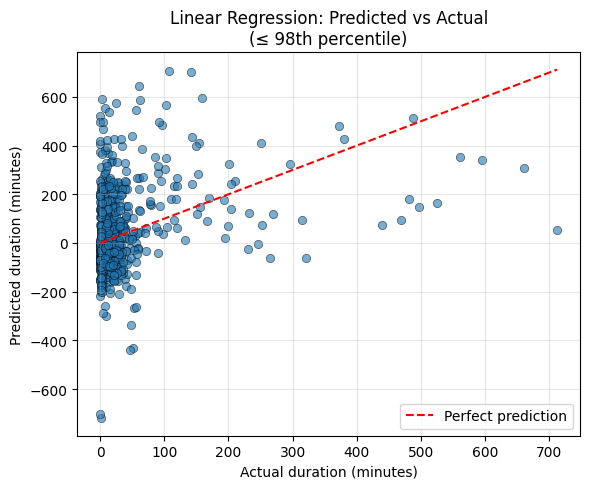


Training XGBoost...

XGBoost Performance:
MAE: 131.33 min
RMSE: 901.92 min
R²: -6.0968


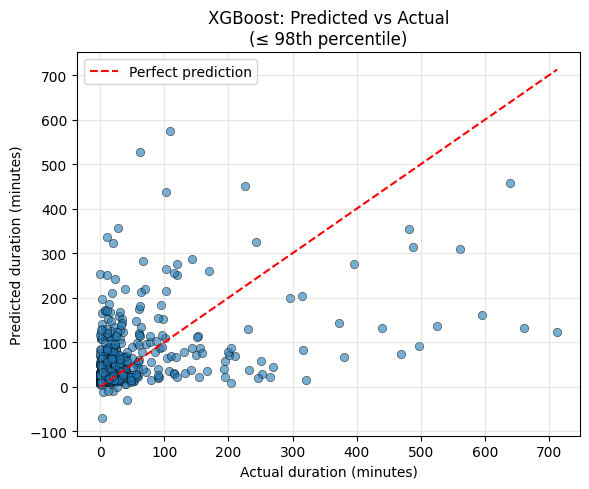


Test set evaluation (XGBoost):

XGBoost (Test) Performance:
MAE: 84.87 min
RMSE: 465.61 min
R²: -0.0088


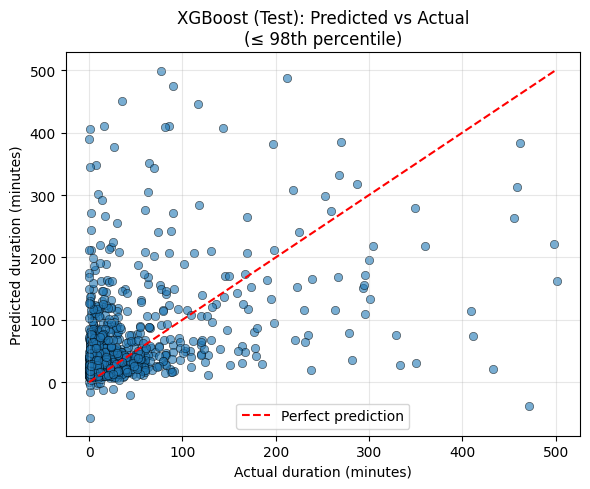

In [7]:
X, y, df_spikes = prepare_spike_dataset(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, test_size=0.2, val_size=0.1, random_state=42)

print("Training Linear Regression...")
lr_model, lr_train_pred, lr_val_pred = train_linear_regression(X_train, y_train, X_val, y_val)
lr_metrics = evaluate_model(y_val, lr_val_pred, "Linear Regression", quantile_cut=0.98)

print("\nTraining XGBoost...")
xgb_model, xgb_train_pred, xgb_val_pred = train_xgboost(X_train, y_train, X_val, y_val)
xgb_metrics = evaluate_model(y_val, xgb_val_pred, "XGBoost", quantile_cut=0.98)

print("\nTest set evaluation (XGBoost):")
y_test_pred = xgb_model.predict(X_test)
test_metrics = evaluate_model(y_test, y_test_pred, "XGBoost (Test)", quantile_cut=0.98)



МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ НА ВСЕХ ВЫБОРКАХ

Train:
  Linear Regression -> MAE=743.82 min, RMSE=1330.01 min, R²=0.1891, MAPE=6482.45%
  XGBoost           -> MAE=345.60 min, RMSE=609.14 min, R²=0.8299, MAPE=3145.17%

Val:
  Linear Regression -> MAE=597.26 min, RMSE=1017.58 min, R²=0.2106, MAPE=10538.77%
  XGBoost           -> MAE=445.66 min, RMSE=895.54 min, R²=0.3886, MAPE=4357.21%

Test:
  Linear Regression -> MAE=766.31 min, RMSE=1698.62 min, R²=0.1331, MAPE=5813.81%
  XGBoost           -> MAE=607.94 min, RMSE=1505.06 min, R²=0.3194, MAPE=2998.93%

ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ

Linear Regression Coefficients & Significance:
                   Feature   Coefficient    Std_Error   t_statistic      p_value  Significant
             rate_slope_1h -9.134330e+03 1.754672e+03 -5.205718e+00 2.419852e-07         True
       avg_rate_24h_before -7.123015e+03 2.495217e+03 -2.854667e+00 4.412026e-03         True
       spread_to_base_rate  3.685287e+03 1.635390e+03  2.253460e+00 2.448188e-02         Tru

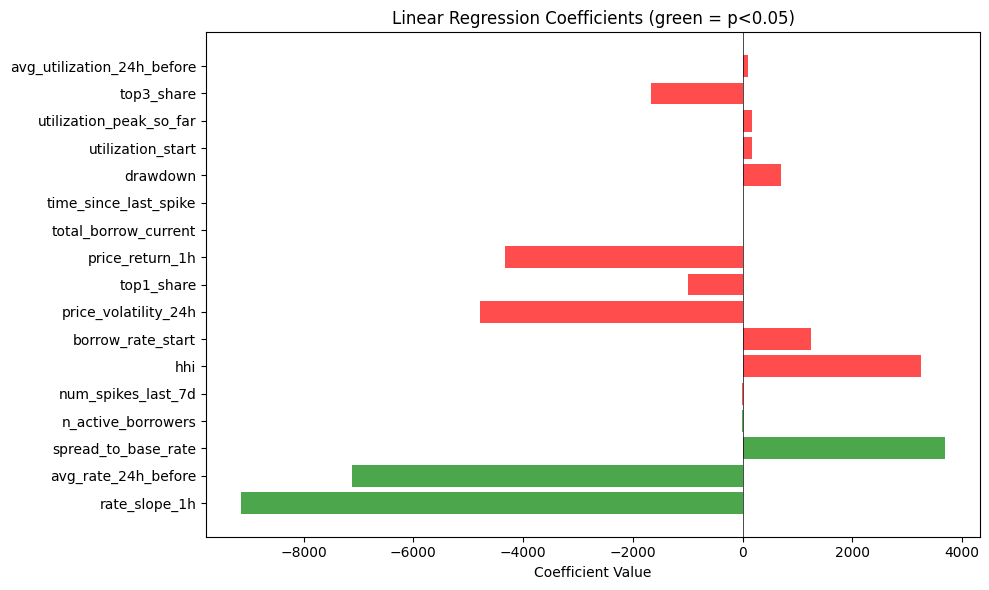


XGBoost Feature Importance:
                   Feature  Importance  Importance_pct
        n_active_borrowers    0.134210       13.421042
             rate_slope_1h    0.120277       12.027691
      price_volatility_24h    0.098971        9.897080
        num_spikes_last_7d    0.074893        7.489301
       avg_rate_24h_before    0.061937        6.193691
      total_borrow_current    0.061866        6.186567
     time_since_last_spike    0.061764        6.176365
avg_utilization_24h_before    0.057322        5.732231
                top1_share    0.051523        5.152331
       spread_to_base_rate    0.049329        4.932939
                       hhi    0.047925        4.792504
                top3_share    0.044486        4.448630
         borrow_rate_start    0.037558        3.755771
         utilization_start    0.035018        3.501842
           price_return_1h    0.031532        3.153196
                  drawdown    0.031388        3.138818
   utilization_peak_so_far    0.0000

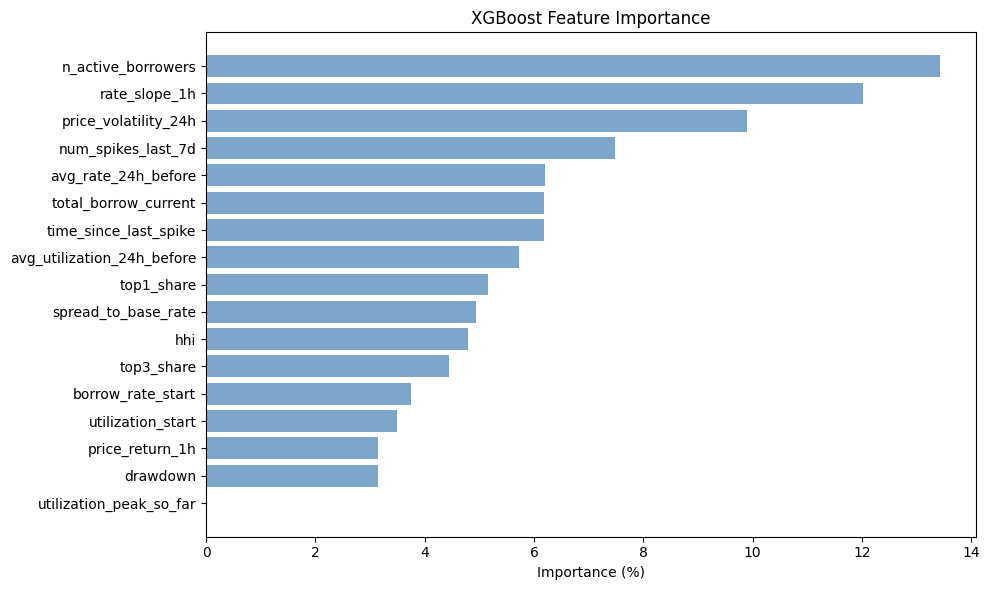

,Feature,Importance,Importance_pct
6,n_active_borrowers,0.134210,13.421042
3,rate_slope_1h,0.120277,12.027691
11,price_volatility_24h,0.098971,9.897080
15,num_spikes_last_7d,0.074893,7.489301
14,avg_rate_24h_before,0.061937,6.193691
5,total_borrow_current,0.061866,6.186567
16,time_since_last_spike,0.061764,6.176365
13,avg_utilization_24h_before,0.057322,5.732231
7,top1_share,0.051523,5.152331
4,spread_to_base_rate,0.049329,4.932939


In [ ]:

# ------------------------------------------------------------
# Основной блок: обучение и оценка
# Предполагаем, что df_long уже загружен
# ------------------------------------------------------------
X, y, df_first = prepare_spike_dataset(df)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

# Линейная регрессия
lr_model, y_pred_train_lr, y_pred_val_lr = train_linear_regression(X_train, y_train, X_val, y_val)
y_pred_test_lr = lr_model.predict(X_test)

# XGBoost
xgb_model, y_pred_train_xgb, y_pred_val_xgb = train_xgboost(X_train, y_train, X_val, y_val)
y_pred_test_xgb = xgb_model.predict(X_test)

# Функция для расчёта метрик (включая MAPE)
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # MAPE – избегаем деления на 0
    mask = y_true > 1e-6
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, r2, mape

# Вывод по всем выборкам
print("\n" + "="*80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ НА ВСЕХ ВЫБОРКАХ")
print("="*80)
for name, y_true, y_pred_lr, y_pred_xgb in [
    ("Train", y_train, y_pred_train_lr, y_pred_train_xgb),
    ("Val",   y_val,   y_pred_val_lr,   y_pred_val_xgb),
    ("Test",  y_test,  y_pred_test_lr,  y_pred_test_xgb)
]:
    lr_mae, lr_rmse, lr_r2, lr_mape = compute_metrics(y_true, y_pred_lr)
    xgb_mae, xgb_rmse, xgb_r2, xgb_mape = compute_metrics(y_true, y_pred_xgb)
    print(f"\n{name}:")
    print(f"  Linear Regression -> MAE={lr_mae:.2f} min, RMSE={lr_rmse:.2f} min, R²={lr_r2:.4f}, MAPE={lr_mape:.2f}%")
    print(f"  XGBoost           -> MAE={xgb_mae:.2f} min, RMSE={xgb_rmse:.2f} min, R²={xgb_r2:.4f}, MAPE={xgb_mape:.2f}%")

# Дополнительно: коэффициенты линейной модели и важность XGBoost
print("\n" + "="*80)
print("ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ")
print("="*80)
report_linear_coefficients(lr_model, X.columns, X_train, y_train)
report_xgboost_importance(xgb_model, X.columns)



Linear Regression Coefficients & Significance:
                   Feature   Coefficient    Std_Error  t_statistic      p_value  Significant
avg_utilization_24h_before -1.407083e+03 1.356046e+02   -10.376361 0.000000e+00         True
             rate_slope_1h -1.005168e+03 1.351988e+02    -7.434745 1.803002e-13         True
        num_spikes_last_7d -2.979501e+00 5.783155e-01    -5.152033 2.939322e-07         True
                       hhi -1.485745e+00 4.809477e-01    -3.089202 2.045891e-03         True
        n_active_borrowers -8.354938e-01 4.113557e-01    -2.031074 4.243345e-02         True
                top3_share  1.037809e+02 6.867181e+01     1.511258 1.309451e-01        False
      total_borrow_current  1.811064e-07 2.593562e-07     0.698292 4.851088e-01        False
       avg_rate_24h_before  3.465986e+02 5.049639e+02     0.686383 4.925837e-01        False
      price_volatility_24h -2.637857e+02 4.229400e+02    -0.623695 5.329279e-01        False
         utilization_s

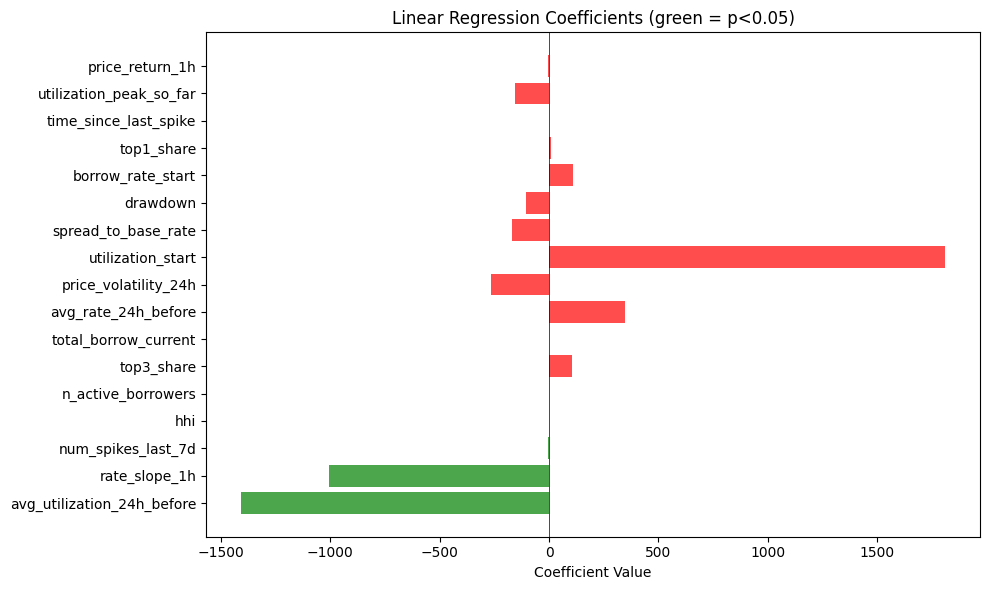


XGBoost Feature Importance:
                   Feature  Importance  Importance_pct
        n_active_borrowers    0.200087       20.008728
avg_utilization_24h_before    0.150034       15.003441
             rate_slope_1h    0.087674        8.767433
      price_volatility_24h    0.085226        8.522577
     time_since_last_spike    0.073441        7.344141
       avg_rate_24h_before    0.065232        6.523204
        num_spikes_last_7d    0.049893        4.989285
                top3_share    0.045184        4.518373
       spread_to_base_rate    0.039690        3.969006
                       hhi    0.031156        3.115553
                top1_share    0.030403        3.040286
         utilization_start    0.030172        3.017177
                  drawdown    0.029737        2.973731
      total_borrow_current    0.029584        2.958448
         borrow_rate_start    0.029565        2.956476
   utilization_peak_so_far    0.017101        1.710096
           price_return_1h    0.0058

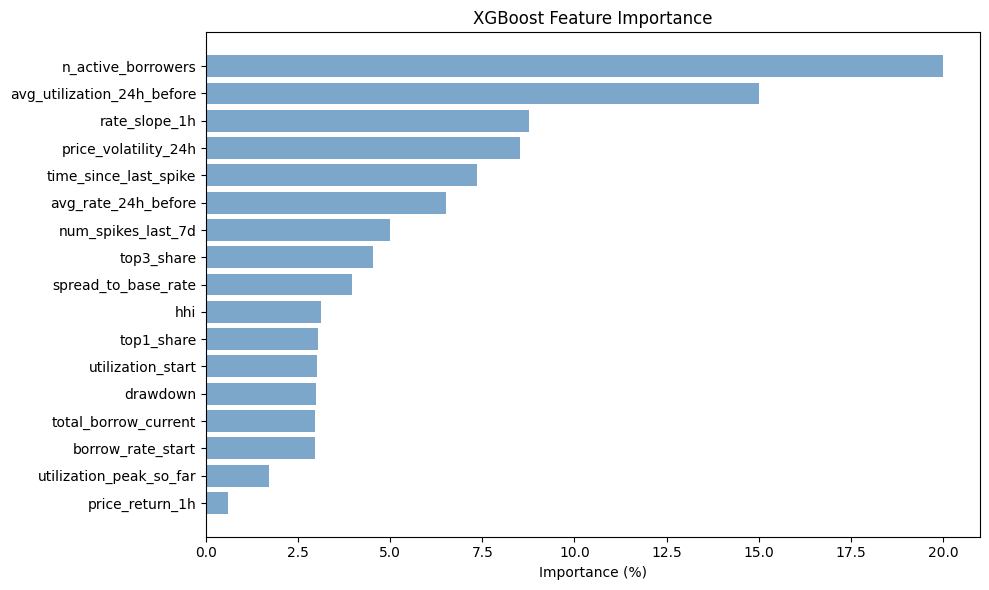

In [ ]:
feature_names = X.columns.tolist()

lr_coef_df = report_linear_coefficients(lr_model, feature_names, X_train, y_train)

xgb_imp_df = report_xgboost_importance(xgb_model, feature_names)


### **Classification models - whether spike was closed before 1 hours / n hours**

In [54]:
df_w_stress

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,supplier_hhi,supplier_top1_share,supplier_top3_share,supplier_n_active,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,top_suppliers_at_start,top1_supplier_stress_index,top2_supplier_stress_index,top3_supplier_stress_index,top3_supplier_stress_index_mean,top1_supplier_mean_util_top1_market,top1_supplier_mean_util_top3_markets,top1_supplier_address,top2_supplier_address,top3_supplier_address
0,eth_usr_usdc,0,0.0,0.934907,0.934907,0.934907,0.145688,-0.138547,0.011329,2.702005e+06,17,0.310315,0.639467,0.185496,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,84.0,84,1.736301e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.900000,0.900000,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
1,eth_usr_usdc,0,1.4,0.934907,0.936187,0.936187,0.145688,-0.138547,0.011329,2.705706e+06,17,0.309890,0.639960,0.185446,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,0.0,84,1.736302e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.900000,0.900000,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
2,eth_usr_usdc,1,0.0,0.969926,0.969926,0.969926,0.220655,-0.055102,0.086526,2.705707e+06,17,0.309890,0.639960,0.185446,0.388110,0.508074,1.0,4,0.000000,0.005975,0.000997,0.747252,0.190007,1,168.0,4836.0,4836,1.736302e+09,1.736302e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.900000,0.900000,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
3,eth_usr_usdc,1,30.0,0.969926,0.999680,0.999680,0.220655,-0.055102,0.086526,2.788726e+06,18,0.300662,0.650682,0.185135,0.388110,0.508074,1.0,4,0.000000,0.005975,0.000997,0.747252,0.190007,1,168.0,3036.0,4836,1.736303e+09,1.736302e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.900000,0.900000,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
4,eth_usr_usdc,1,60.0,0.969926,0.995712,0.999680,0.220655,-0.055102,0.086526,2.788794e+06,18,0.300662,0.650682,0.185135,0.388899,0.509684,1.0,4,-0.003101,0.006775,0.004095,0.747252,0.190007,1,168.0,1236.0,4836,1.736305e+09,1.736302e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.900000,0.900000,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32002,eth_syrupusdc_pyusd,6051,30.0,0.995152,0.995152,0.995152,0.148241,0.000000,NaN,6.589888e+06,12,0.776260,1.000000,0.634792,1.000000,1.000000,1.0,4,0.000000,0.000000,0.000000,0.900000,0.038459,0,1566492.0,3096.0,4896,1.769579e+09,1.769577e+09,0 0x19b3cD7032B8C062E8d44EaCad661a0970DD8c5...,12.360323,0.610788,0.673778,12.360323,1.000000,0.966671,0x19b3cD7032B8C062E8d44EaCad661a0970DD8c55,other,NaN
32003,eth_syrupusdc_pyusd,6051,60.0,0.995152,0.995152,0.995152,0.148241,0.000000,NaN,6.589888e+06,12,0.776260,1.000000,0.634792,1.000000,1.000000,1.0,4,0.000124,0.000124,0.000000,0.900000,0.038459,0,1566492.0,1296.0,4896,1.769581e+09,1.769577e+09,0 0x19b3cD7032B8C062E8d44EaCad661a0970DD8c5...,7.800441,0.610788,0.673778,7.800441,1.0000

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import statsmodels.api as sm
import optuna

def prepare_classification_dataset(df_long, threshold_minutes=60):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    df_first['target'] = (df_first['spike_duration_minutes'] > threshold_minutes).astype(int)
    
    feature_cols = [
        'utilization_start', 'utilization_peak_so_far', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike',
        "supplier_n_active", 'supplier_top1_share', 'supplier_top3_share', 'supplier_hhi', 

        "top1_supplier_stress_index", "top2_supplier_stress_index", "top3_supplier_stress_index", "top3_supplier_stress_index_mean", "top1_supplier_mean_util_top1_market", "top1_supplier_mean_util_top3_markets"
    ]
    X = df_first[feature_cols].fillna(0)
    y = df_first['target']
    return X, y, df_first

def train_logistic_regression(X_train, y_train, X_val, y_val):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_val = model.predict(X_val)
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]
    return model, y_pred_train, y_pred_proba_train, y_pred_val, y_pred_proba_val

def report_logistic_coefficients(model, feature_names, X_train, y_train):
    X_with_const = sm.add_constant(X_train)
    logit_model = sm.Logit(y_train, X_with_const)
    result = logit_model.fit(disp=0)
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': result.params[1:].values,
        'Std_Error': result.bse[1:].values,
        'z_statistic': result.tvalues[1:].values,
        'p_value': result.pvalues[1:].values,
        'Significant': result.pvalues[1:].values < 0.05
    }).sort_values('p_value')
    
    print("\nLogistic Regression Coefficients & Significance:")
    print(coef_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if p < 0.05 else 'red' for p in coef_df['p_value']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Logistic Regression Coefficients (green = p<0.05)')
    plt.tight_layout()
    plt.show()
    
    return coef_df

def evaluate_classification(y_true, y_pred, y_pred_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.colorbar()
    tick_marks = [0, 1]
    plt.xticks(tick_marks, ['Short (≤1h)', 'Long',])
    plt.yticks(tick_marks, ['Short (≤1h)', 'Long',])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.tight_layout()
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

def train_xgboost_classifier(X_train, y_train, X_val, y_val, use_optuna=False, n_trials=50):
    if use_optuna:
        def objective(trial):
            class_weight_param = trial.suggest_float('class_weight', 1, 50, log=True)
            
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'gamma': trial.suggest_float('gamma', 0, 5),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
                'random_state': 42,
                'use_label_encoder': False,
                'eval_metric': 'logloss',
                # 'scale_pos_weight': class_weight_param
            }
            model = xgb.XGBClassifier(**params)
            model.fit(X_train, y_train)
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_pred_proba)
            rec = recall_score(y_val, model.predict(X_val), zero_division=0)
            return rec
        
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best_params = study.best_params
        best_params['random_state'] = 42
        model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')
        print(f"Best Optuna params: {study.best_params}")
    else:
        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            random_state=42, use_label_encoder=False, eval_metric='logloss'
        )
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_val = model.predict(X_val)
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]
    return model, y_pred_train, y_pred_proba_train, y_pred_val, y_pred_proba_val

def report_xgboost_classifier_importance(model, feature_names):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    importance_df['Importance_pct'] = importance_df['Importance'] / importance_df['Importance'].sum() * 100
    
    print("\nXGBoost Classifier Feature Importance:")
    print(importance_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance_pct'], alpha=0.7, color='steelblue')
    plt.xlabel('Importance (%)')
    plt.title('XGBoost Classifier Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df


=== Logistic Regression ===

Logistic Regression Performance:
Accuracy:  0.8234
Precision: 0.5000
Recall:    0.0467
F1 Score:  0.0855
ROC AUC:   0.6050


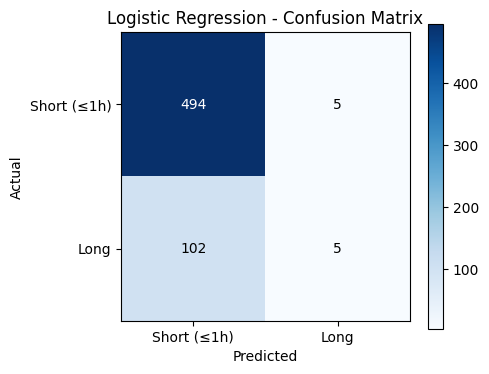

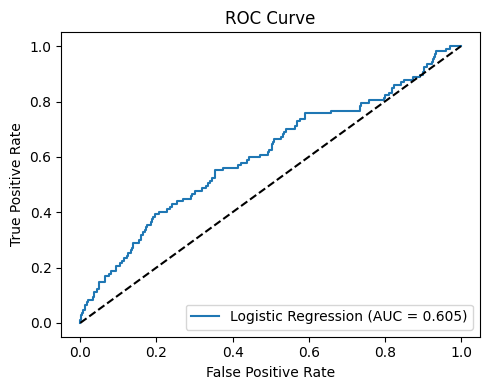


Logistic Regression Coefficients & Significance:
                             Feature   Coefficient    Std_Error   z_statistic      p_value  Significant
                       rate_slope_1h -2.400182e+01 1.154145e+00 -2.079619e+01 4.685723e-96         True
                  num_spikes_last_7d -2.687301e-02 4.209669e-03 -6.383641e+00 1.729266e-10         True
               time_since_last_spike  1.054845e-06 2.071966e-07  5.091033e+00 3.561180e-07         True
                                 hhi -4.235464e-02 8.442421e-03 -5.016883e+00 5.251644e-07         True
                total_borrow_current -7.817749e-09 1.920432e-09 -4.070828e+00 4.684628e-05         True
                 supplier_top3_share -1.856209e-01 4.992990e-02 -3.717630e+00 2.011002e-04         True
          avg_utilization_24h_before  6.584576e-01 1.829452e-01  3.599207e+00 3.191888e-04         True
          top2_supplier_stress_index -2.574132e-01 7.942912e-02 -3.240791e+00 1.191984e-03         True
              

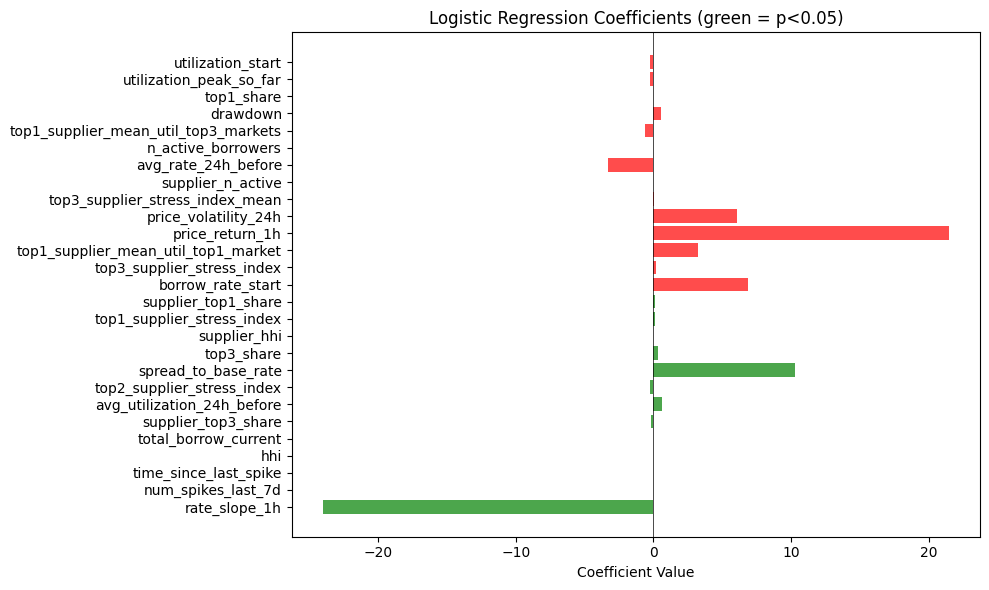


=== XGBoost Classifier (without Optuna) ===

XGBoost Classifier Performance:
Accuracy:  0.8878
Precision: 0.7468
Recall:    0.5514
F1 Score:  0.6344
ROC AUC:   0.9321


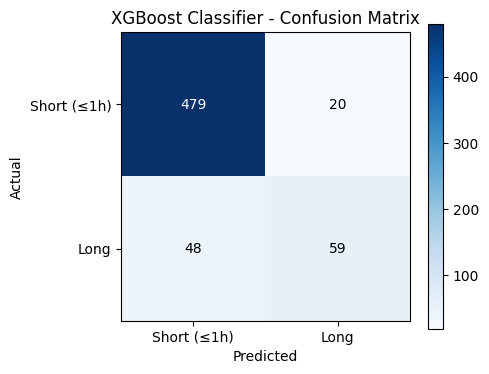

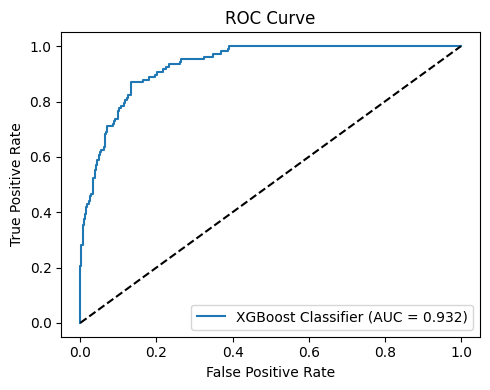


XGBoost Classifier Feature Importance:
                             Feature  Importance  Importance_pct
                       rate_slope_1h    0.171931       17.193083
                  num_spikes_last_7d    0.082359        8.235881
                 spread_to_base_rate    0.060743        6.074349
               time_since_last_spike    0.048264        4.826429
                   utilization_start    0.044059        4.405874
          avg_utilization_24h_before    0.043952        4.395190
     top3_supplier_stress_index_mean    0.041010        4.101031
                 supplier_top3_share    0.037230        3.722958
top1_supplier_mean_util_top3_markets    0.036503        3.650278
          top1_supplier_stress_index    0.033996        3.399584
                          top1_share    0.031288        3.128820
                   supplier_n_active    0.030569        3.056931
                   borrow_rate_start    0.029202        2.920183
                total_borrow_current    0.026347  

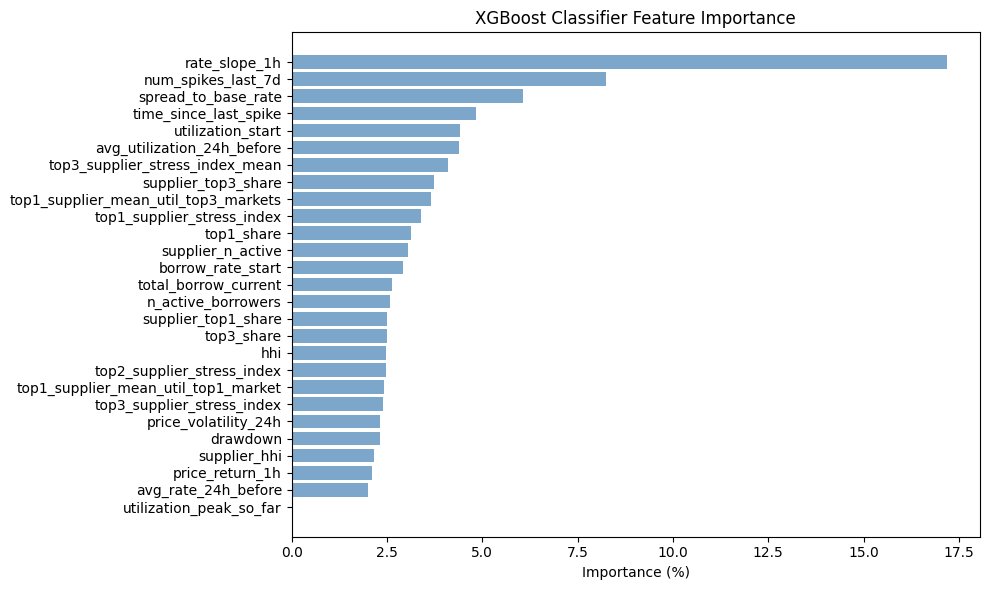


=== XGBoost Classifier (with Optuna) ===


  0%|          | 0/30 [00:00<?, ?it/s]

Best Optuna params: {'class_weight': 3.385890207033226, 'n_estimators': 245, 'max_depth': 8, 'learning_rate': 0.092792044683723, 'subsample': 0.6680856441385356, 'colsample_bytree': 0.9767065586949035, 'gamma': 2.5627791820484913, 'reg_alpha': 0.06558622404183641, 'reg_lambda': 0.011790134175280787}

XGBoost (Optuna) Performance:
Accuracy:  0.8960
Precision: 0.7500
Recall:    0.6168
F1 Score:  0.6769
ROC AUC:   0.9349


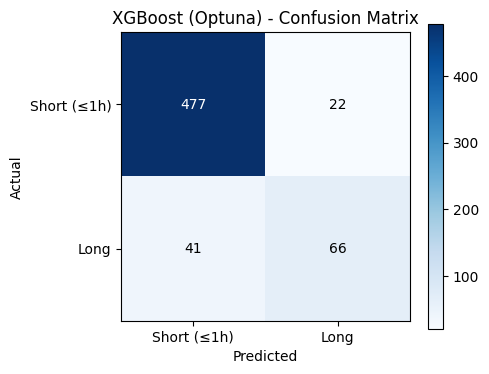

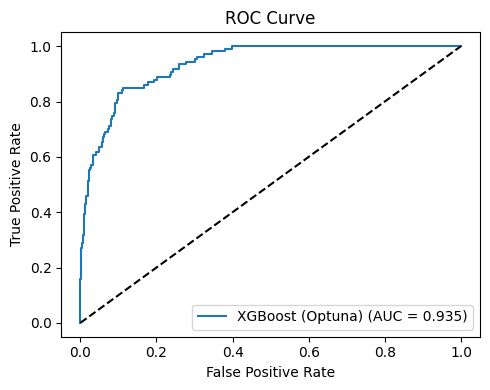

In [75]:
X_cls, y_cls, df_spikes_cls = prepare_classification_dataset(df_w_stress, threshold_minutes=60)

X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = split_data(
    X_cls, y_cls, test_size=0.2, val_size=0.1, random_state=42
)

print("\n=== Logistic Regression ===")
lr_cls, lr_train_pred, lr_train_proba, lr_val_pred, lr_val_proba = train_logistic_regression(
    X_train_c, y_train_c, X_val_c, y_val_c
)
lr_cls_metrics = evaluate_classification(y_val_c, lr_val_pred, lr_val_proba, "Logistic Regression")
lr_coef = report_logistic_coefficients(lr_cls, X_cls.columns.tolist(), X_train_c, y_train_c)

print("\n=== XGBoost Classifier (without Optuna) ===")
xgb_cls, xgb_train_pred, xgb_train_proba, xgb_val_pred, xgb_val_proba = train_xgboost_classifier(
    X_train_c, y_train_c, X_val_c, y_val_c, use_optuna=False
)
xgb_metrics = evaluate_classification(y_val_c, xgb_val_pred, xgb_val_proba, "XGBoost Classifier")
xgb_imp = report_xgboost_classifier_importance(xgb_cls, X_cls.columns.tolist())

print("\n=== XGBoost Classifier (with Optuna) ===")
xgb_opt, _, _, xgb_opt_val_pred, xgb_opt_val_proba = train_xgboost_classifier(
    X_train_c, y_train_c, X_val_c, y_val_c, use_optuna=True, n_trials=30
)
opt_metrics = evaluate_classification(y_val_c, xgb_opt_val_pred, xgb_opt_val_proba, "XGBoost (Optuna)")

In [89]:
df_w_stress['top1_supplier_stress_index'].describe()

count    32007.000000
mean         3.324633
std          4.522504
min          0.078854
25%          0.420057
50%          3.324633
75%          3.324633
max         16.034537
Name: top1_supplier_stress_index, dtype: float64


Market: YB collateral

--- Logistic Regression ---

--- XGBoost (Optuna) ---
XGBoost best params: {'n_estimators': 269, 'max_depth': 10, 'learning_rate': 0.09029802619970204, 'subsample': 0.7131729914499374, 'colsample_bytree': 0.9166459840871426, 'gamma': 3.2908051084273784, 'reg_alpha': 0.006225733794760768, 'reg_lambda': 0.1269191948596812, 'scale_pos_weight': 5.1811437421563875, 'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'}

--- CatBoost (Optuna) ---
CatBoost best params: {'iterations': 275, 'depth': 4, 'learning_rate': 0.06908283417928117, 'l2_leaf_reg': 8.933050029825027, 'border_count': 202, 'random_seed': 42, 'verbose': False, 'eval_metric': 'AUC', 'auto_class_weights': 'Balanced'}

--- Test Performance Summary ---
          Accuracy  Precision_long  Recall_long  F1_long  AUC-ROC  AUC-PR
Model                                                                    
LogReg      0.8406          0.8333       0.0254   0.0493   0.6539  0.3016
XGBoost     0.87

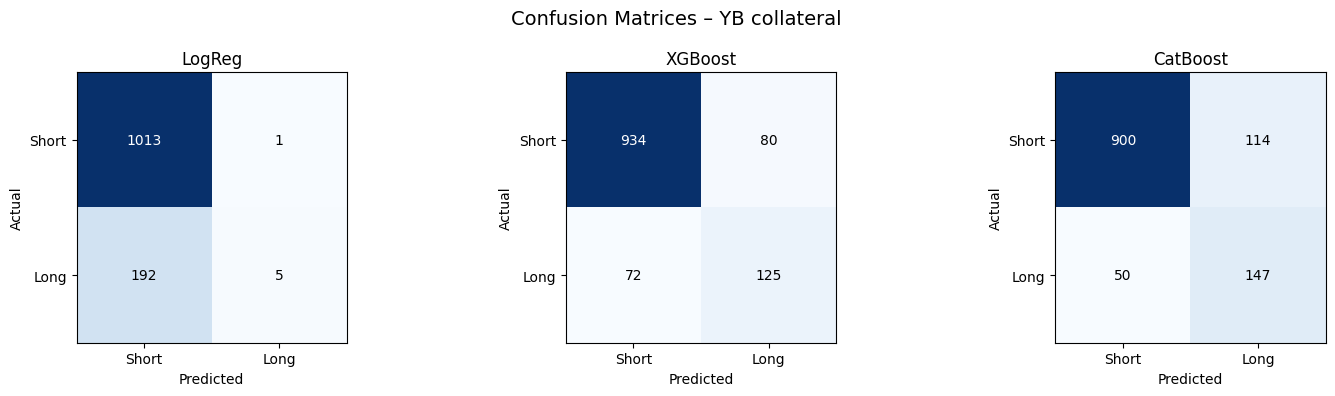

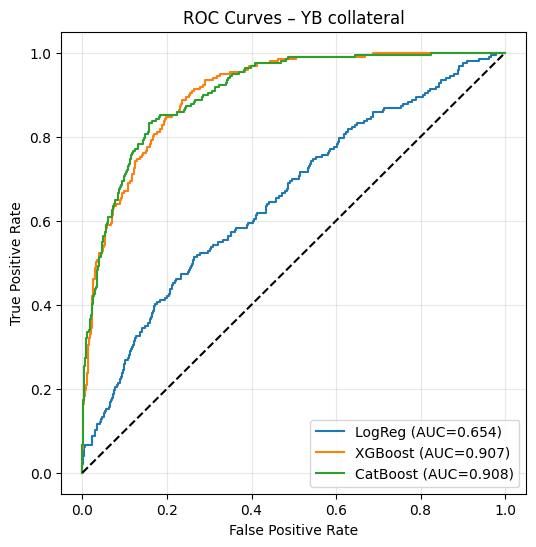

,Accuracy,Precision_long,Recall_long,F1_long,AUC-ROC,AUC-PR
Model,,,,,,
LogReg,0.840628,0.833333,0.025381,0.049261,0.653921,0.301603
XGBoost,0.874484,0.609756,0.634518,0.621891,0.906607,0.679978
CatBoost,0.864575,0.563218,0.746193,0.641921,0.907914,0.697696


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, average_precision_score
)
import statsmodels.api as sm
import optuna
import xgboost as xgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import fbeta_score


# ------------------------------------------------------------
# Подготовка данных
# ------------------------------------------------------------
def prepare_classification_dataset(df_long, threshold_minutes=60):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    df_first['target'] = (df_first['spike_duration_minutes'] > threshold_minutes).astype(int)

    feature_cols = [
        'utilization_start', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike',

        "supplier_n_active", 
        'supplier_top1_share', 'supplier_top3_share', 'supplier_hhi', 

        "top1_supplier_stress_index", "top2_supplier_stress_index", "top3_supplier_stress_index", "top3_supplier_stress_index_mean", "top1_supplier_mean_util_top1_market", "top1_supplier_mean_util_top3_markets"

    ]
    df_first["top1_supplier_stress_index_high_flg"] = (df_first['top1_supplier_stress_index'] > 3).astype(int)
    df_first["top3_supplier_stress_index_mean_high_flg"] = (df_first['top3_supplier_stress_index_mean'] > 3).astype(int)
    df_first["top1_supplier_mean_util_top3_markets_high_flg"] = (df_first['top1_supplier_mean_util_top3_markets'] > 0.95).astype(int)
    
    
    X = df_first[feature_cols].fillna(0)
    y = df_first['target']

    return X, y, feature_cols

# def split_data(X, y, test_size=0.2, val_size=0.1, random_state=42):
#     X_temp, X_test, y_temp, y_test = train_test_split(
#         X, y, test_size=test_size, random_state=random_state
#     )
#     val_ratio = val_size / (1 - test_size)
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_temp, y_temp, test_size=val_ratio, random_state=random_state
#     )
#     return X_train, X_val, X_test, y_train, y_val, y_test

# ------------------------------------------------------------
# Модели с оптимизацией (кроме логистической регрессии)
# ------------------------------------------------------------
def train_logistic_regression(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model
def train_xgboost_optuna(X_train, y_train, X_val, y_val, n_trials=50):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    # Compute class imbalance ratio
    scale_pos_weight_default = (len(y_train) - y_train.sum()) / y_train.sum()
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, scale_pos_weight_default * 5, log=True),
            'random_state': 42,
            'use_label_encoder': False,
            'eval_metric': 'logloss'
        }
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        rec = recall_score(y_val, model.predict(X_val), zero_division=0)
        f2 = fbeta_score(y_val, model.predict(X_val), beta=1.0, zero_division=0)
        return f2  # optimize recall

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best_params = study.best_params
    best_params.update({'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'})
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_train, y_train)
    print(f"XGBoost best params: {best_params}")
    return model

def train_catboost_optuna(X_train, y_train, X_val, y_val, n_trials=50):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 50, 300),
            'depth': trial.suggest_int('depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'random_seed': 42,
            'verbose': False,
            'eval_metric': 'AUC',
            'auto_class_weights': 'Balanced'  # handle imbalance automatically
        }
        model = CatBoostClassifier(**params)
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        rec = recall_score(y_val, model.predict(X_val), zero_division=0)
        f2 = fbeta_score(y_val, model.predict(X_val), beta=1.0, zero_division=0)
        return f2

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best_params = study.best_params
    best_params.update({'random_seed': 42, 'verbose': False, 'eval_metric': 'AUC', 'auto_class_weights': 'Balanced'})
    model = CatBoostClassifier(**best_params)
    model.fit(X_train, y_train)
    print(f"CatBoost best params: {best_params}")
    return model

# ------------------------------------------------------------
# Метрики
# ------------------------------------------------------------
def compute_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_long': precision_score(y_true, y_pred, zero_division=0),
        'Recall_long': recall_score(y_true, y_pred, zero_division=0),
        'F1_long': f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'AUC-PR': average_precision_score(y_true, y_proba)
    }

# ------------------------------------------------------------
# Основной эксперимент для одного типа рынка
# ------------------------------------------------------------
def run_classification_experiment(df_long, market_label, n_trials=30):
    print(f"\n{'='*60}")
    print(f"Market: {market_label}")
    X, y, feature_names = prepare_classification_dataset(df_long, threshold_minutes=60)
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, )

    results = {}

    # LogReg (без оптимизации)
    print("\n--- Logistic Regression ---")
    lr = train_logistic_regression(X_train, y_train)
    y_test_pred = lr.predict(X_test)
    y_test_proba = lr.predict_proba(X_test)[:, 1]
    results['LogReg'] = compute_metrics(y_test, y_test_pred, y_test_proba)

    # XGBoost (Optuna)
    print("\n--- XGBoost (Optuna) ---")
    xgb_model = train_xgboost_optuna(X_train, y_train, X_val, y_val, n_trials)
    y_test_pred1 = xgb_model.predict(X_test)
    y_test_proba1 = xgb_model.predict_proba(X_test)[:, 1]
    results['XGBoost'] = compute_metrics(y_test, y_test_pred1, y_test_proba1)

    # CatBoost (Optuna)
    print("\n--- CatBoost (Optuna) ---")
    cb_model = train_catboost_optuna(X_train, y_train, X_val, y_val, n_trials)
    y_test_pred2 = cb_model.predict(X_test)
    y_test_proba2 = cb_model.predict_proba(X_test)[:, 1]
    results['CatBoost'] = compute_metrics(y_test, y_test_pred2, y_test_proba2)

    # Сводка
    summary = pd.DataFrame(results).T
    summary.index.name = 'Model'
    print("\n--- Test Performance Summary ---")
    print(summary.round(4).to_string())

    # Визуализации
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    models_plot = [('LogReg', lr, y_test_pred), ('XGBoost', xgb_model, y_test_pred1),
                   ('CatBoost', cb_model, y_test_pred2)]
    for ax, (name, model, preds) in zip(axes, models_plot):
        cm = confusion_matrix(y_test, preds)
        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(name)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Short','Long']); ax.set_yticklabels(['Short','Long'])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                        color='white' if cm[i,j] > cm.max()/2 else 'black')
    fig.suptitle(f'Confusion Matrices – {market_label}', fontsize=14)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,6))
    for name, model, proba in [('LogReg', lr, y_test_proba),
                               ('XGBoost', xgb_model, y_test_proba1),
                               ('CatBoost', cb_model, y_test_proba2)]:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves – {market_label}')
    plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.show()

    return summary

# ------------------------------------------------------------
# Пример запуска (замените на свои датафреймы)
# ------------------------------------------------------------
# Допустим, df_volatile, df_yb, df_pt уже содержат данные одного типа рынка.
# summary_vol = run_classification_experiment(df_volatile, 'Volatile collateral')
# summary_yb   = run_classification_experiment(df_yb, 'YB')
# summary_pt   = run_classification_experiment(df_pt, 'PT')

# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_CRYPTO_tokens.csv")
# run_classification_experiment(df, "Volatile collateral", n_trials=30)

# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_YB_tokens.csv")
# run_classification_experiment(df, "YB collateral", n_trials=30)
run_classification_experiment(df_w_stress, "YB collateral", n_trials=50)



# --- Test Performance Summary --- (reference)
#           Accuracy  Precision_long  Recall_long  F1_long  AUC-ROC  AUC-PR
# Model                                                                    
# LogReg      0.8401          0.8333       0.0294   0.0568   0.6138  0.2870
# XGBoost     0.8988          0.7407       0.5882   0.6557   0.9192  0.7416
# CatBoost    0.8988          0.7642       0.5529   0.6416   0.9200  0.7400


# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv")
# run_classification_experiment(df, "PT collateral", n_trials=30)

# --- Test Performance Summary ---  # no suppliers info
#           Accuracy  Precision_long  Recall_long  F1_long  AUC-ROC  AUC-PR
# Model                                                                    
# LogReg      0.8382          0.5556       0.0254   0.0485   0.6456  0.2766
# XGBoost     0.8745          0.6027       0.6701   0.6346   0.9115  0.6952
# CatBoost    0.8770          0.6121       0.6650   0.6375   0.8977  0.6909


# --- Test Performance Summary ---  # suppliers - only hhi + shares
#           Accuracy  Precision_long  Recall_long  F1_long  AUC-ROC  AUC-PR
# Model                                                                    
# LogReg      0.8406          0.8333       0.0254   0.0493   0.6542  0.3026
# XGBoost     0.8687          0.5872       0.6497   0.6019   0.8984  0.6883
# CatBoost    0.8505          0.5290       0.6911   0.6003   0.8999  0.6827


# --- Test Performance Summary ---  # suppliers - hhi + shares + stress factors
#           Accuracy  Precision_long  Recall_long  F1_long  AUC-ROC  AUC-PR
# Model                                                                    
# LogReg      0.8406          0.8333       0.0254   0.0493   0.6539  0.3016
# XGBoost     0.8745          0.6098       0.6345   0.6219   0.9066  0.6800
# CatBoost    0.8646          0.5632       0.7462   0.6419   0.9079  0.6977



### **Hazard modeling (bins)**

In [93]:
df.head(2)

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,supplier_hhi,supplier_top1_share,supplier_top3_share,supplier_n_active,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,top_suppliers_at_start
0,eth_usr_usdc,0,0.0,0.934907,0.934907,0.934907,0.145688,-0.138547,0.011329,2.702005e+06,17,0.310315,0.639467,0.185496,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,84.0,84,1.736301e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...
1,eth_usr_usdc,0,1.4,0.934907,0.936187,0.936187,0.145688,-0.138547,0.011329,2.705706e+06,17,0.309890,0.639960,0.185446,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,0.0,84,1.736302e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...


In [92]:
df_w_stress.head(2)

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,supplier_hhi,supplier_top1_share,supplier_top3_share,supplier_n_active,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,top_suppliers_at_start,top1_supplier_stress_index,top2_supplier_stress_index,top3_supplier_stress_index,top3_supplier_stress_index_mean,top1_supplier_mean_util_top1_market,top1_supplier_mean_util_top3_markets,top1_supplier_address,top2_supplier_address,top3_supplier_address
0,eth_usr_usdc,0,0.0,0.934907,0.934907,0.934907,0.145688,-0.138547,0.011329,2.702005e+06,17,0.310315,0.639467,0.185496,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,84.0,84,1.736301e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.9,0.9,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78
1,eth_usr_usdc,0,1.4,0.934907,0.936187,0.936187,0.145688,-0.138547,0.011329,2.705706e+06,17,0.309890,0.639960,0.185446,0.396914,0.525201,1.0,4,0.000999,0.005975,0.000997,0.749911,0.194015,0,NaN,0.0,84,1.736302e+09,1.736301e+09,1 0x132E6C9C33A62D7727cd359b1f51e5B566E485E...,3.324633,0.610788,0.673778,2.622946,0.9,0.9,0x132E6C9C33A62D7727cd359b1f51e5B566E485Eb,0xd63070114470f685b75B74D60EEc7c1113d33a3D,0x8A25d8C9fa8C7A726137f2D618d85CbC2C083F78


In [100]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from lifelines.utils import concordance_index

# BINS_MINUTES = [0, 30, 120, 360, 1440]
BINS_MINUTES = range(0, 60*24, 30)
BINS_MINUTES = [0, 60, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]
BINS_MINUTES = [0, 60, 120, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]

def prepare_hazard_dataset(df_long, bins=BINS_MINUTES, delta_features=None):
    if delta_features is None:
        delta_features = []

    df = df_long.copy()
    df['duration_minutes'] = df['spike_duration_seconds'] / 60.0
    rows = []

    for spike_idx, group in df.groupby('spike_index'):
        group = group.sort_values('time_offset_minutes')
        duration = group['duration_minutes'].iloc[0]

        start_mask = group['time_offset_minutes'] == 0
        if not start_mask.any():
            continue
        start_row = group[start_mask].iloc[0]

        tol = 0
        for i in range(len(bins) - 1):
            bin_start = bins[i]
            bin_end = bins[i + 1]
            mask = group['time_offset_minutes'] == bin_start
            if not mask.any():
                continue
            row_at_start = group[mask].iloc[0].copy()

            event = 1 if (duration > bin_start and duration <= bin_end) else 0
            if tol > 0:
                event = 1
            if i == len(bins) - 2:
                event = 1

            for feat in delta_features:
                start_val = start_row.get(feat, np.nan)
                bin_val = row_at_start.get(feat, np.nan)
                row_at_start[f'{feat}_vs_start'] = bin_val - start_val if pd.notna(start_val) and pd.notna(bin_val) else np.nan

            row_at_start['bin_start'] = bin_start
            row_at_start['bin_end'] = bin_end
            row_at_start['bin_label'] = f"{bin_start}-{bin_end}m"
            row_at_start['event'] = event
            row_at_start['bin_idx'] = i
            rows.append(row_at_start)

            if event == 1 or duration <= bin_start:
                tol += 1
                if tol >= 3:
                    break

    return pd.DataFrame(rows)

def train_hazard_model(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

def display_hazard_model_coefficients(model, feature_names):
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    print("Top Features by Absolute Coefficient Magnitude:")
    print(coef_df.head(10).to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'].head(15), coef_df['Coefficient'].head(15), color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Hazard Model - Top 15 Feature Coefficients')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return coef_df


def evaluate_hazard_model(model, X_val, y_val, hazard_val):
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    brier = brier_score_loss(y_val, y_pred_proba)
    c_index = concordance_index(hazard_val['duration_minutes'], -y_pred_proba, y_val)
    print(f"Validation AUC: {auc:.4f}")
    print(f"Validation Brier Score: {brier:.4f}")
    print(f"Concordance Index: {c_index:.4f}")

    bin_brier = {}
    for bin_label in hazard_val['bin_label'].unique():
        mask = hazard_val['bin_label'] == bin_label
        if mask.sum() > 0:
            bin_brier[bin_label] = brier_score_loss(y_val[mask], y_pred_proba[mask])
    print("\nBrier Score per bin:")
    for bin_label, score in bin_brier.items():
        print(f"{bin_label}: {score:.4f}")

    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'LogReg (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Hazard Model')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_pred_proba

def plot_calibration(y_true, y_pred_proba, n_bins=10):
    from sklearn.calibration import calibration_curve
    prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=n_bins)
    plt.figure(figsize=(5,4))
    plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
    plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Calibration Plot')
    plt.legend()
    plt.tight_layout()
    plt.show()

def predict_survival_curve(model, X_spike_start, bins=BINS_MINUTES):
    bin_starts = bins[:-1]
    pred_probs = []
    X_repeated = pd.DataFrame(np.repeat(X_spike_start.values, len(bin_starts), axis=0), columns=X_spike_start.columns)
    prob_event = model.predict_proba(X_repeated)[:, 1]
    surv = [1.0]
    for i, p in enumerate(prob_event):
        surv.append(surv[-1] * (1 - p))
    return np.array(bins), np.array(surv)

def plot_survival_examples_grid_best_predictions(model, X_val, hazard_val, n_examples_per_row=10, bins=BINS_MINUTES):
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    
    spike_errors = []
    for _, spike_row in unique_spikes.iterrows():
        spike_idx = spike_row['spike_index']
        true_duration = spike_row['duration_minutes']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_duration = predict_expected_duration(model, X_spike, bins)
        error = abs(true_duration - pred_duration)
        spike_errors.append({
            'spike_index': spike_idx,
            'duration_minutes': true_duration,
            'pred_duration': pred_duration,
            'abs_error': error
        })
    
    errors_df = pd.DataFrame(spike_errors)
    
    durations = errors_df['duration_minutes']
    short_threshold = 60 * 1
    long_threshold = 60 * 3
    
    errors_df['category'] = 'Medium'
    errors_df.loc[errors_df['duration_minutes'] <= short_threshold, 'category'] = 'Short'
    errors_df.loc[errors_df['duration_minutes'] > long_threshold, 'category'] = 'Long'
    
    best_short = errors_df[errors_df['category'] == 'Short'].nsmallest(10, 'abs_error')
    best_medium = errors_df[errors_df['category'] == 'Medium'].nsmallest(10, 'abs_error')
    best_long = errors_df[errors_df['category'] == 'Long'].nsmallest(10, 'abs_error')
    
    fig, axes = plt.subplots(3, n_examples_per_row, figsize=(4*n_examples_per_row, 12))
    
    row_labels = ['Short Spikes', 'Medium Spikes', 'Long Spikes']
    spike_groups = [best_short, best_medium, best_long]
    
    for row_idx, (spike_group, label) in enumerate(zip(spike_groups, row_labels)):
        n_sample = min(n_examples_per_row, len(spike_group))
        if n_sample == 0:
            for col_idx in range(n_examples_per_row):
                axes[row_idx, col_idx].set_visible(False)
            continue
            
        sample_spikes = spike_group.sample(n=n_sample, random_state=42)
        
        for col_idx, (_, spike_row) in enumerate(sample_spikes.iterrows()):
            spike_idx = spike_row['spike_index']
            true_duration = spike_row['duration_minutes']
            pred_duration = spike_row['pred_duration']
            error = spike_row['abs_error']
            mask = hazard_val['spike_index'] == spike_idx
            X_spike = X_val.loc[mask].iloc[[0]]
            
            times, surv = predict_survival_curve(model, X_spike, bins)
            
            ax = axes[row_idx, col_idx]
            ax.step(times, surv, where='post', linewidth=2)
            ax.axvline(x=true_duration, color='red', linestyle='--', linewidth=1.5, label=f'True: {true_duration:.0f}m')
            ax.axvline(x=pred_duration, color='blue', linestyle=':', linewidth=1.5, label=f'Pred: {pred_duration:.0f}m')
            ax.set_xlabel('Time (minutes)')
            ax.set_ylabel('Survival probability')
            ax.set_title(f'Spike {spike_idx}')
            ax.legend(loc='lower left', fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.05)
        
        for col_idx in range(n_sample, n_examples_per_row):
            axes[row_idx, col_idx].set_visible(False)
        
        axes[row_idx, 0].set_ylabel(f'{label}\nSurvival probability')
    
    plt.suptitle('Best Predicted Survival Curves by Duration Category (Top 10 per category)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_kaplan_meier_style_comparison(model, X_val, hazard_val, bins=BINS_MINUTES, n_bootstrap=100, clip=1440):
    from sklearn.utils import resample
    
    unique_spikes = hazard_val.groupby('spike_index').first().reset_index()
    true_durations = unique_spikes['duration_minutes'].values
    
    pred_durations = []
    for idx, row in unique_spikes.iterrows():
        mask = hazard_val['spike_index'] == row['spike_index']
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_durations.append(predict_expected_duration(model, X_spike, bins))
    pred_durations = np.array(pred_durations)
    
    plt.figure(figsize=(6, 6))
    mask = (true_durations < clip) & (pred_durations < clip)
    true_durations = true_durations[mask]
    pred_durations = pred_durations[mask]
    
    plt.scatter(true_durations, pred_durations, alpha=0.6, edgecolors='k', linewidth=0.5)
    max_val = max(true_durations.max(), pred_durations.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Actual duration (minutes)')
    plt.ylabel('Predicted expected duration (minutes)')
    plt.title('Actual vs Predicted Expected Duration')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    mae = np.mean(np.abs(true_durations - pred_durations))
    print(f"MAE of expected duration: {mae:.2f} minutes")

def predict_expected_duration(model, X_spike, bins=BINS_MINUTES):
    times, surv = predict_survival_curve(model, X_spike, bins)
    expected_duration = 0
    for i in range(len(times) - 1):
        expected_duration += surv[i] * (times[i+1] - times[i])
    return expected_duration



def compute_survival_slope(times, surv):
    slope, _ = np.polyfit(times, surv, 1)
    return slope

def compute_slopes_for_spikes(model, X_val, hazard_val, bins=BINS_MINUTES):
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    slopes = []
    durations = []
    for _, spike_row in unique_spikes.iterrows():
        spike_idx = spike_row['spike_index']
        true_duration = spike_row['duration_minutes']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        times, surv = predict_survival_curve(model, X_spike, bins)
        slope = compute_survival_slope(times, surv)
        slopes.append(slope)
        durations.append(true_duration)
    return np.array(slopes), np.array(durations)

def analyze_slopes_by_duration(slopes, durations):
    # short_threshold = np.percentile(durations, 33)
    # long_threshold = np.percentile(durations, 67)
    slopes = slopes * 30
    short_threshold = 60
    long_threshold = 60*3
    
    
    categories = []
    for d in durations:
        if d <= short_threshold:
            categories.append('Short')
        elif d <= long_threshold:
            categories.append('Medium')
        else:
            categories.append('Long')
    
    df_slopes = pd.DataFrame({'slope': slopes, 'category': categories})
    
    print("Survival Curve Slope (negative = decline) by Actual Duration:")
    print(df_slopes.groupby('category')['slope'].describe()[['mean', '50%', 'std']].to_string())
    print("\nInterpretation: More negative slope = faster decline (typical for short spikes).\n")
    
    df_slopes.boxplot(column='slope', by='category', grid=False, figsize=(8,5))
    plt.title('Survival Curve Slope by Spike Duration Category')
    plt.suptitle('')
    plt.ylabel('Slope (Δsurvival / minute)')
    plt.xlabel('Duration Category')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    return df_slopes


In [96]:
df_w_stress.columns

Index(['market', 'spike_index', 'time_offset_minutes', 'utilization_start',
       'utilization_current', 'utilization_peak_so_far', 'borrow_rate_start',
       'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
       'n_active_borrowers', 'top1_share', 'top3_share', 'hhi', 'supplier_hhi',
       'supplier_top1_share', 'supplier_top3_share', 'supplier_n_active',
       'price_return_1h', 'price_volatility_24h', 'drawdown',
       'avg_utilization_24h_before', 'avg_rate_24h_before',
       'num_spikes_last_7d', 'time_since_last_spike',
       'remaining_duration_seconds', 'spike_duration_seconds',
       'cutoff_timestamp', 'spike_trigger_timestamp', 'top_suppliers_at_start',
       'top1_supplier_stress_index', 'top2_supplier_stress_index',
       'top3_supplier_stress_index', 'top3_supplier_stress_index_mean',
       'top1_supplier_mean_util_top1_market',
       'top1_supplier_mean_util_top3_markets', 'top1_supplier_address',
       'top2_supplier_address', 'top3_supplie

Validation AUC: 0.8017
Validation Brier Score: 0.1801
Concordance Index: 0.7906

Brier Score per bin:
30-60m: 0.2503
60-180m: 0.2394
0-30m: 0.2094
390-420m: 0.0781
270-300m: 0.1483
900-930m: 0.0002
990-1020m: 0.1230
1020-1050m: 0.0001
180-240m: 0.2240
360-390m: 0.0669
570-600m: 0.1347
240-270m: 0.1785
660-690m: 0.0427
480-510m: 0.0917
330-360m: 0.1099
420-450m: 0.0641
690-720m: 0.1072
300-330m: 0.1060
510-540m: 0.0643
450-480m: 0.0451
840-870m: 0.0550
960-990m: 0.0001
780-810m: 0.0815
930-960m: 0.0001
750-780m: 0.0958
1110-1140m: 0.0000
720-750m: 0.0013
870-900m: 0.0970
630-660m: 0.0562
540-570m: 0.0663
1200-1230m: 0.1656
1320-1350m: 0.0908
1140-1170m: 0.0000
1290-1320m: 0.0000
600-630m: 0.0060
1080-1110m: 0.1970
1170-1200m: 0.1103
810-840m: 0.0006
1260-1290m: 0.1807
1050-1080m: 0.0000
1380-1410m: 0.9983
1230-1260m: 0.0000
1350-1380m: 0.0000


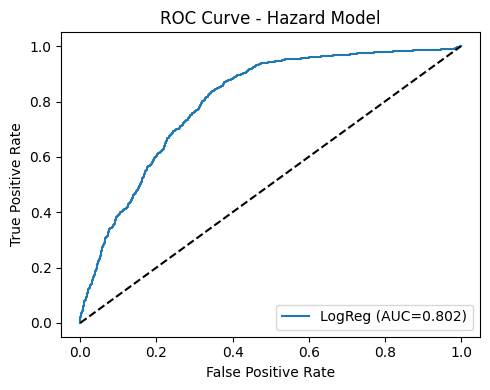

Validation AUC: 0.8079
Validation Brier Score: 0.1774
Concordance Index: 0.7916

Brier Score per bin:
930-960m: 0.0610
180-240m: 0.2062
60-180m: 0.2382
1290-1320m: 0.0665
660-690m: 0.0805
0-30m: 0.2117
240-270m: 0.1712
30-60m: 0.2470
600-630m: 0.0387
420-450m: 0.0645
810-840m: 0.0437
390-420m: 0.0735
960-990m: 0.0001
570-600m: 0.0577
1140-1170m: 0.1127
330-360m: 0.1095
1080-1110m: 0.0718
690-720m: 0.0649
750-780m: 0.0143
360-390m: 0.0919
300-330m: 0.1463
900-930m: 0.0335
780-810m: 0.0263
270-300m: 0.1416
870-900m: 0.0003
1200-1230m: 0.0461
450-480m: 0.0846
540-570m: 0.0390
1350-1380m: 0.0624
1110-1140m: 0.0211
480-510m: 0.0511
1320-1350m: 0.0000
990-1020m: 0.0528
1020-1050m: 0.0186
1050-1080m: 0.0165
630-660m: 0.0724
720-750m: 0.0727
1170-1200m: 0.0903
510-540m: 0.0626
840-870m: 0.0004
1260-1290m: 0.0000
1230-1260m: 0.0486
1380-1410m: 0.9983


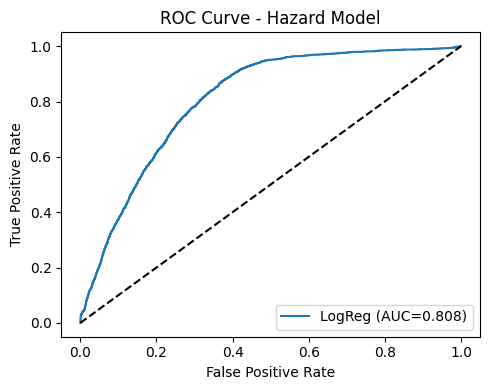

Top Features by Absolute Coefficient Magnitude:
                        Feature  Coefficient
                        bin_idx    -0.162470
     top1_supplier_stress_index    -0.026082
top3_supplier_stress_index_mean    -0.024848
             num_spikes_last_7d     0.022066
     avg_utilization_24h_before    -0.005479
              utilization_start    -0.005246
            utilization_current    -0.005189
                     top3_share    -0.005154
                     top1_share    -0.003870
                            hhi    -0.002707


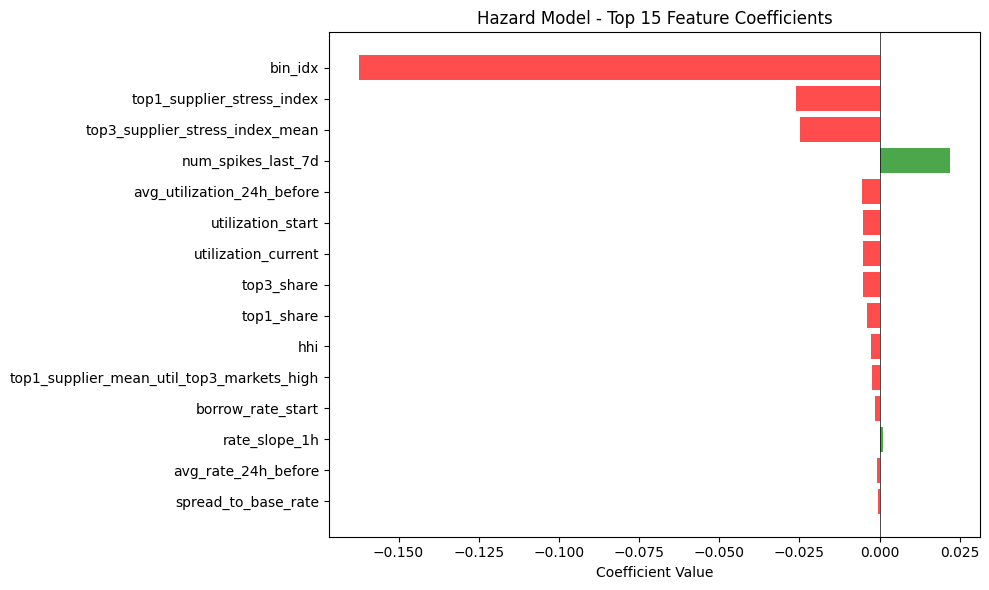

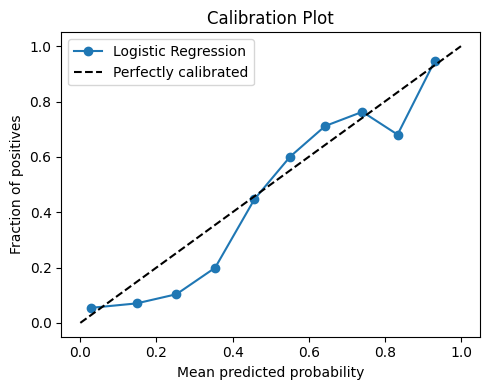

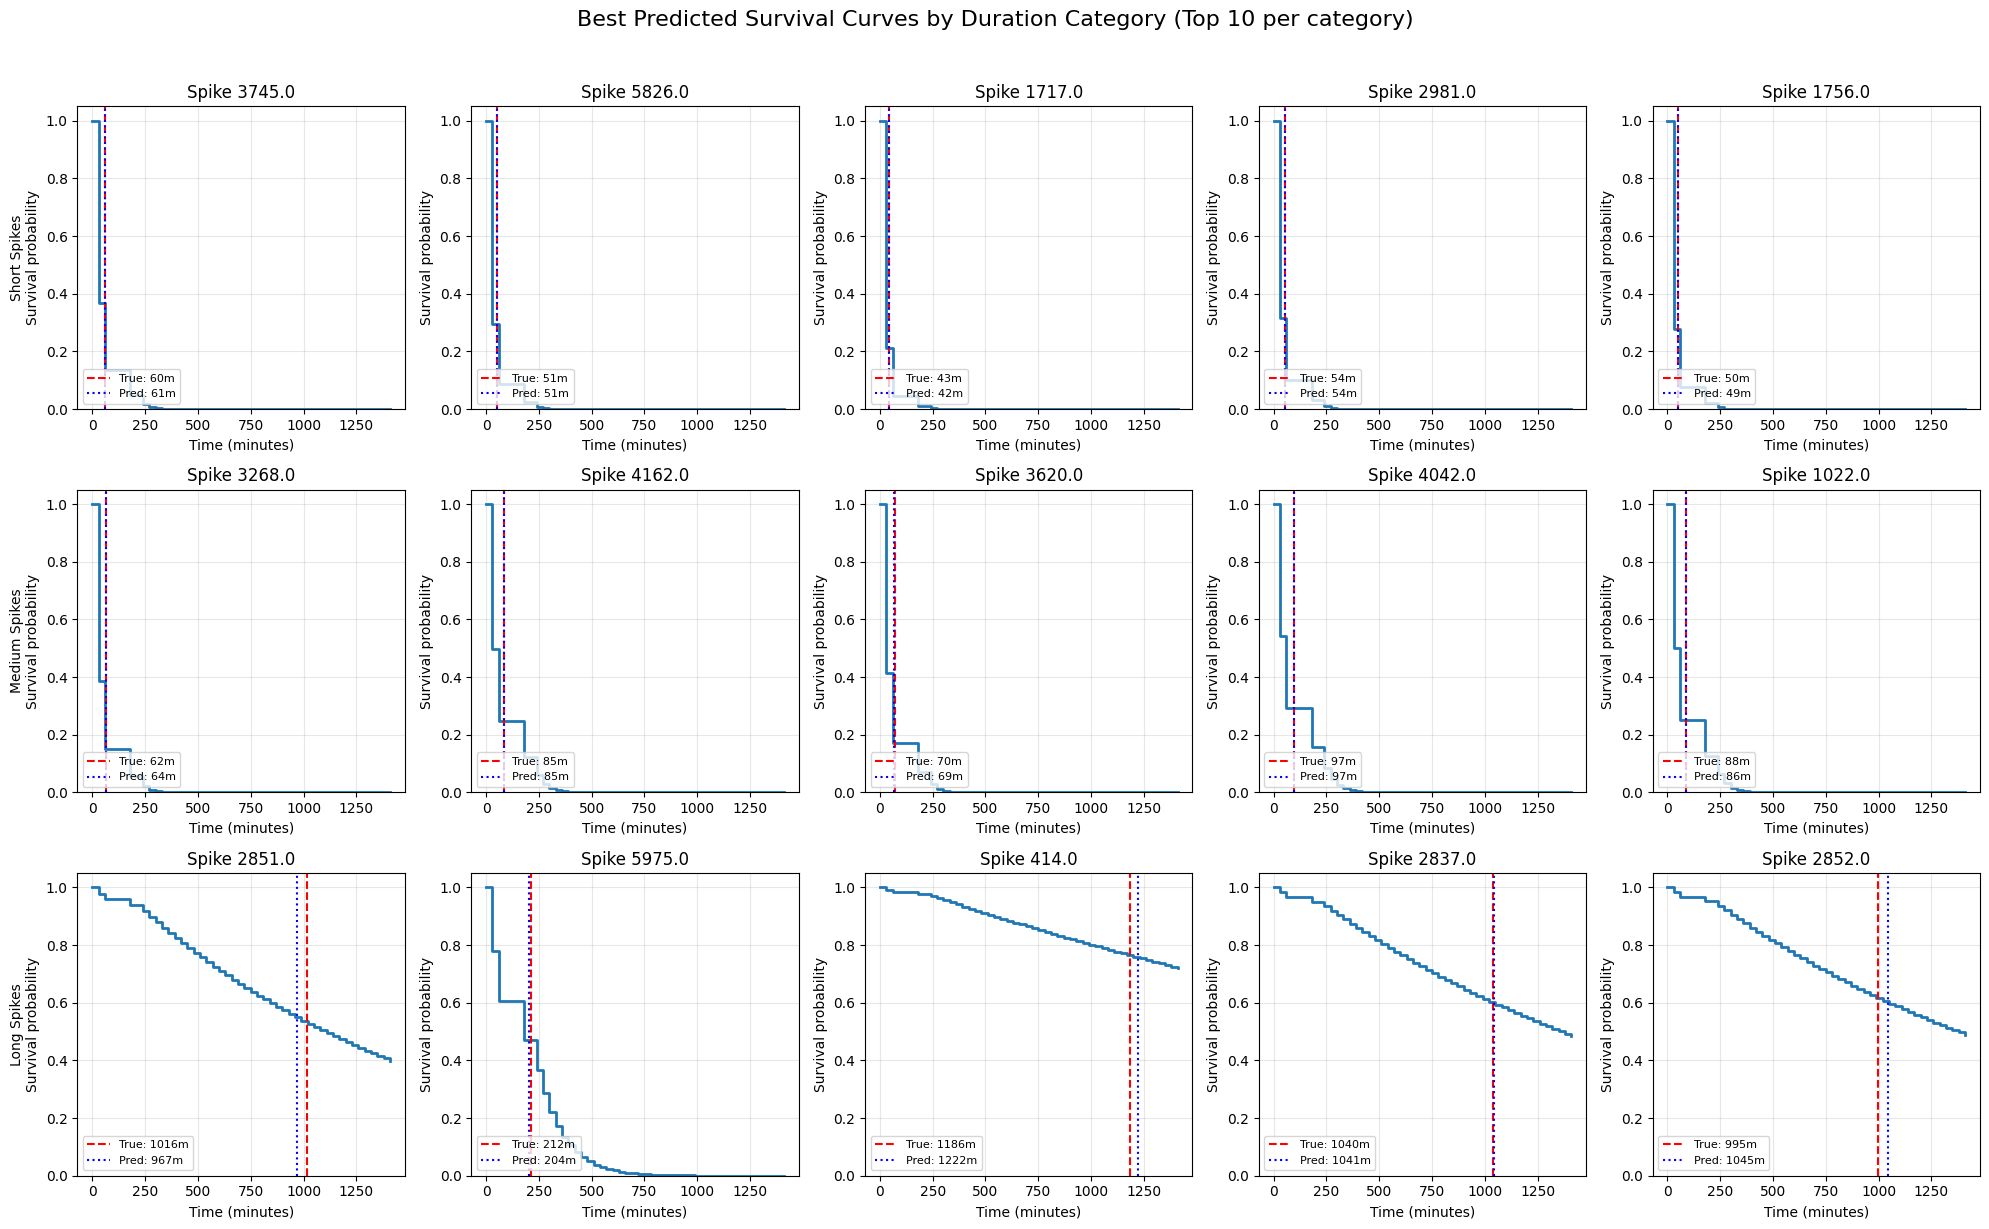

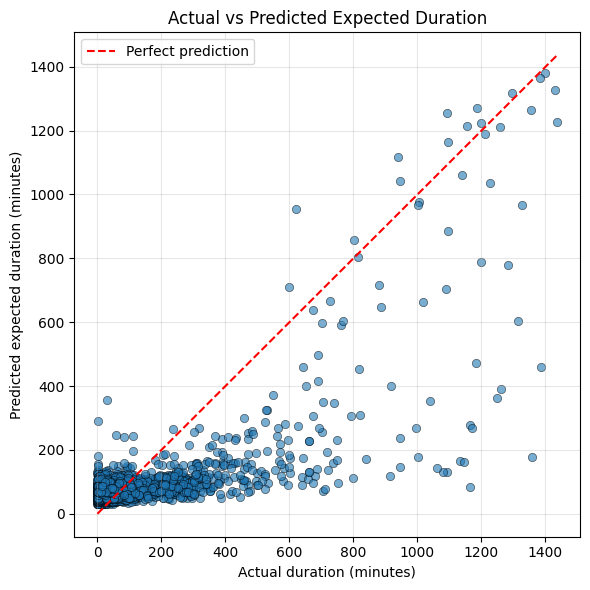

MAE of expected duration: 64.63 minutes
Survival Curve Slope (negative = decline) by Actual Duration:
              mean       50%       std
category                              
Long     -0.008874 -0.007286  0.003990
Medium   -0.005858 -0.005752  0.001110
Short    -0.005275 -0.005220  0.000861

Interpretation: More negative slope = faster decline (typical for short spikes).



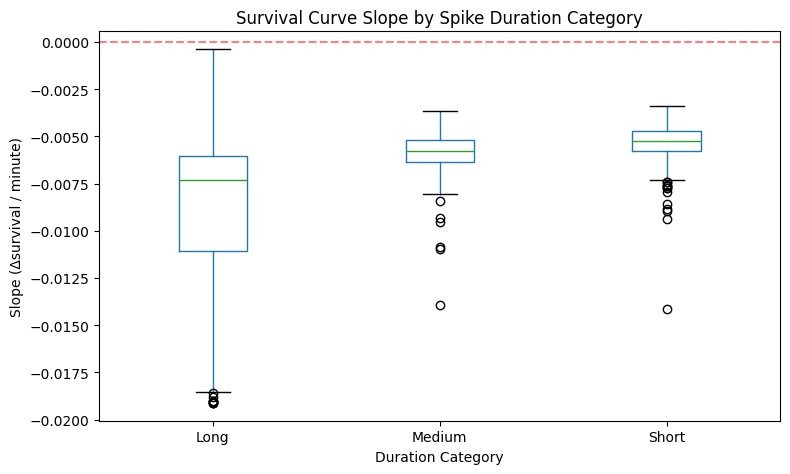

,slope,category
0,-0.005558,Medium
1,-0.006673,Medium
2,-0.004236,Medium
3,-0.005038,Short
4,-0.013420,Long
...,...,...
1768,-0.005204,Short
1769,-0.006147,Short
1770,-0.005151,Short
1771,-0.004816,Medium


In [101]:
# df_prep = df.copy()
# df_prep = df_prep[
#     df_prep["spike_duration_seconds"] > 60*60 * 2
# ]
# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_CRYPTO_tokens.csv")
# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_YB_tokens.csv")
BINS_MINUTES = [0, 30, 60, 180, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]
# BINS_MINUTES = [0, 180, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]

BIN_LABELS = []
for i in range(len(BINS_MINUTES)-1): BIN_LABELS.append(f"{BINS_MINUTES[i-1]}-{BINS_MINUTES[i]}m")


# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv")
# df_prep = df.copy()
df_prep = df_w_stress.copy()
# df_prep = df_prep[
#     df_prep["spike_duration_seconds"] > 60*60 * 2
# ]
hazard_df = prepare_hazard_dataset(df_prep, bins=BINS_MINUTES)

feature_cols = [
    'utilization_start', 'borrow_rate_start',
    'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
    'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
    'price_return_1h', 'price_volatility_24h', 'drawdown',
    'avg_utilization_24h_before', 'avg_rate_24h_before',
    'num_spikes_last_7d', 'time_since_last_spike',

    'utilization_current',
    # 'time_offset_minutes',
    'bin_idx',
    # 'utilization_peak_so_far',

    'top1_supplier_stress_index', 'top3_supplier_stress_index_mean', 'top1_supplier_mean_util_top3_markets_high'
]
hazard_df['top1_supplier_mean_util_top3_markets_high'] = (hazard_df['top1_supplier_mean_util_top3_markets'] >= 0.94).astype(int)
X = hazard_df[feature_cols].fillna(0)
y = hazard_df['event']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
val_idx = X_val.index
hazard_val = hazard_df.loc[val_idx]
hazard_train = hazard_df.loc[X_train.index]

model = train_hazard_model(X_train, y_train)
y_pred_proba = evaluate_hazard_model(model, X_val, y_val, hazard_val)
y_pred_proba_train = evaluate_hazard_model(model, X_train, y_train, hazard_train)

display_hazard_model_coefficients(model, feature_cols)

# plot_calibration(y_val, y_pred_proba)
plot_calibration(y_train, y_pred_proba_train)

plot_survival_examples_grid_best_predictions(model, X_val, hazard_val, n_examples_per_row=5, bins=BINS_MINUTES)
# plot_kaplan_meier_style_comparison(model, X_val, hazard_val, bins=BINS_MINUTES)
plot_kaplan_meier_style_comparison(model, X_train, hazard_train, bins=BINS_MINUTES)


slopes, durations = compute_slopes_for_spikes(model, X_val, hazard_val, bins=BINS_MINUTES)
analyze_slopes_by_duration(slopes, durations)



Survival probability at 30 min by duration category:
              mean       50%       std
category                              
Long      0.720286  0.721271  0.170009
Medium    0.513061  0.536453  0.145033
Short     0.425607  0.462332  0.181878


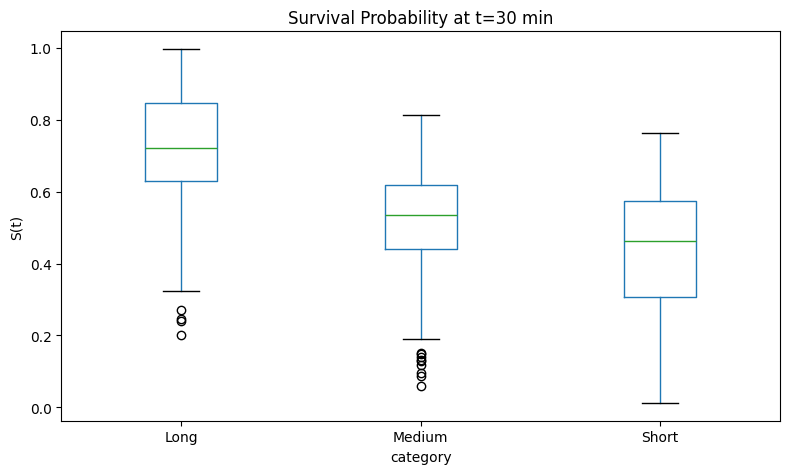


Survival probability at 120 min by duration category:
              mean       50%       std
category                              
Long      0.547594  0.520231  0.233851
Medium    0.284180  0.287784  0.133712
Short     0.214084  0.213751  0.139135


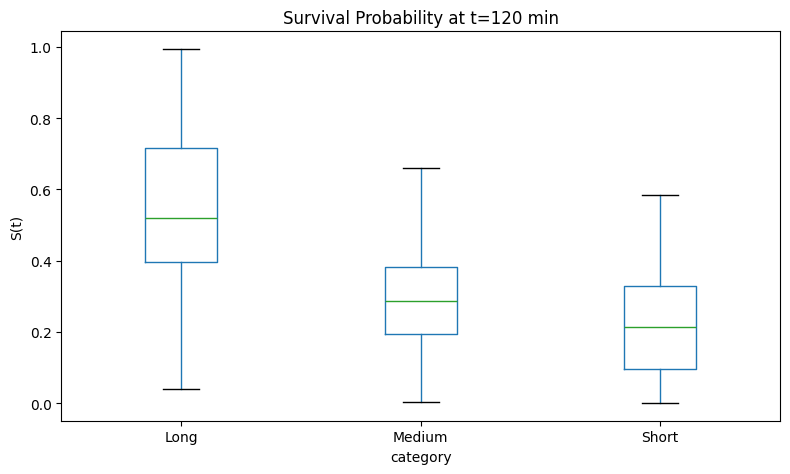


Survival probability at 360 min by duration category:
              mean       50%       std
category                              
Long      0.197987  0.073246  0.260261
Medium    0.015769  0.006860  0.023827
Short     0.008418  0.002088  0.014430


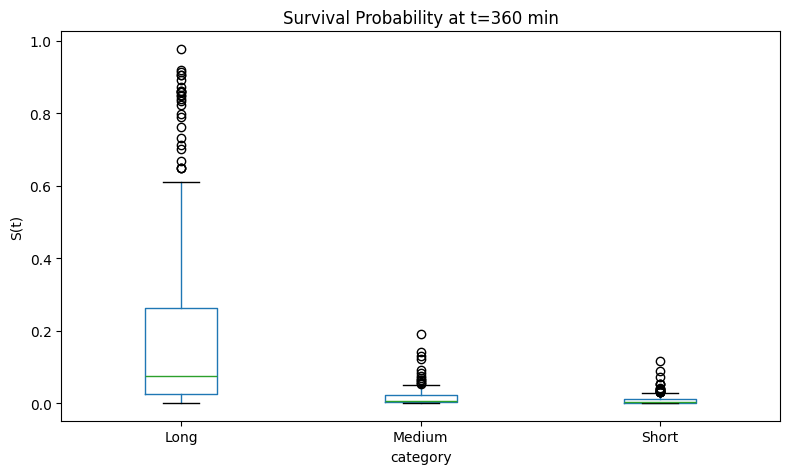

In [10]:
def analyze_survival_at_horizon(model, X_val, hazard_val, horizon_minutes, bins=BINS_MINUTES):
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    surv_at_horizon = []
    durations = []
    for _, spike in unique_spikes.iterrows():
        mask = hazard_val['spike_index'] == spike['spike_index']
        X_spike = X_val.loc[mask].iloc[[0]]
        times, surv = predict_survival_curve(model, X_spike, bins)
        idx = np.searchsorted(times, horizon_minutes, side='right') - 1
        if idx >= 0:
            surv_val = surv[idx]
        else:
            surv_val = 1.0
        surv_at_horizon.append(surv_val)
        durations.append(spike['duration_minutes'])

    durations = np.array(durations)
    surv_at_horizon = np.array(surv_at_horizon)

    short_threshold = np.percentile(durations, 33)
    long_threshold = np.percentile(durations, 67)
    categories = np.where(durations <= short_threshold, 'Short',
                 np.where(durations <= long_threshold, 'Medium', 'Long'))

    df_surv = pd.DataFrame({
        'survival': surv_at_horizon,
        'duration_minutes': durations,
        'category': categories
    })

    print(f"\nSurvival probability at {horizon_minutes} min by duration category:")
    print(df_surv.groupby('category')['survival'].describe()[['mean', '50%', 'std']])

    df_surv.boxplot(column='survival', by='category', grid=False, figsize=(8,5))
    plt.title(f'Survival Probability at t={horizon_minutes} min')
    plt.suptitle('')
    plt.ylabel('S(t)')
    plt.tight_layout()
    plt.show()
for horizon in [30, 120, 360]:
    analyze_survival_at_horizon(model, X_val, hazard_val, horizon)


AAAAA 0 [ 0.   7.3 14.6 21.9 29.2]
[1.0, 0.20090198323747277, 0.04036160686874979, 0.008108726866583036, 0.0016290593090275104, 0.0003272812459950939, 6.575145139684555e-05, 1.320959698636857e-05, 2.653834232329189e-06, 5.331605604584302e-07, 1.0711301398010114e-07, 2.1519216939145466e-08, 4.323253360791742e-09, 8.685501742211304e-10, 1.744934525422776e-10, 3.5056080677697403e-11, 7.042836132682257e-12, 1.4149197466723985e-12, 2.8426018322834743e-13, 5.710843456602239e-14, 1.147319776390134e-14, 2.304988184843517e-15, 4.630766976740051e-16, 9.303302695376722e-17, 1.8690519621597094e-17, 3.754962459717755e-18, 7.543794051395559e-19, 1.5155631860604175e-19, 3.044796498012408e-20, 6.117056550052046e-21, 1.2289287924812291e-21, 2.4689423166711154e-22, 4.960154079181476e-23, 9.965047916709991e-24, 2.0019978895234837e-24, 4.022053464425028e-25, 8.080385176901363e-26, 1.623365407362161e-26, 3.2613732985816604e-27, 6.55216363762794e-28, 1.316342669295907e-28, 2.6445585288165646e-29, 5.31297053

KeyError: 9467

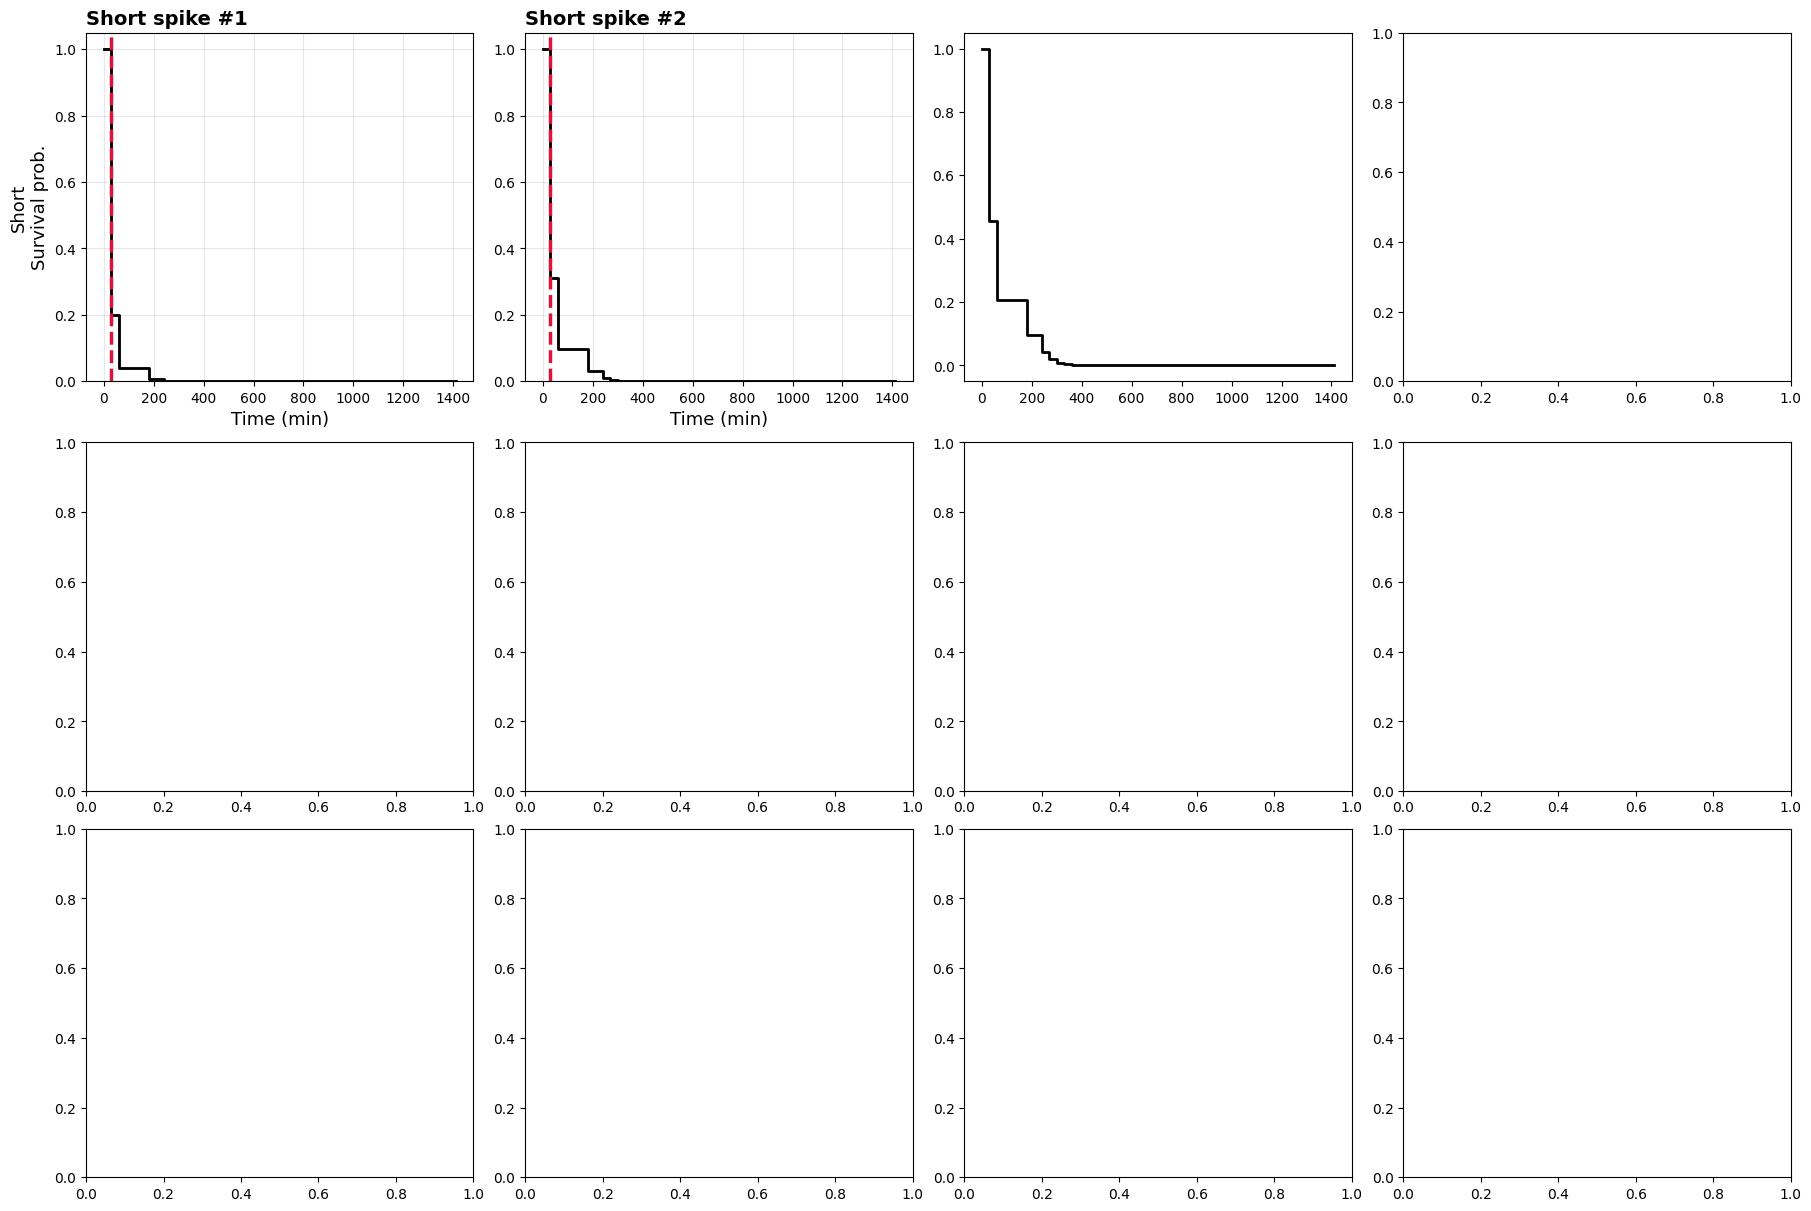

In [44]:
def predict_survival_curve_from_state(model, X_row, bins, t_obs):
    """
    Compute conditional survival curve given that spike is alive at t_obs,
    using features X_row (row from hazard_df at the bin start ≤ t_obs).
    Assumes features remain fixed from t_obs onward.
    Returns array of future bin boundaries and survival probabilities.
    """
    # Find index of the first bin boundary strictly > t_obs
    i_start = np.searchsorted(bins, t_obs, side='right')
    # The bin we are in is [bins[i_start-1], bins[i_start])
    future_bins = bins[i_start-1:]   # start from the boundary before t_obs
    prob_event = model.predict_proba(X_row.values.reshape(1, -1))[0, 1]
    surv = [1.0]
    surv.append(surv[-1] * (1 - prob_event))
    # For subsequent bins we would need updated features; here we reuse X_row
    # so the hazard remains constant for all future intervals.
    for _ in range(i_start, len(bins)-1):
        prob_event_future = model.predict_proba(X_row.values.reshape(1, -1))[0, 1]
        surv.append(surv[-1] * (1 - prob_event_future))
    return future_bins, np.array(surv)


def plot_survival_evolution(
    model,
    X_val,
    hazard_val,
    bins,
    n_examples_per_row=3,
    curves_cnt=4,
    short_threshold=60,
    long_threshold=180,
    random_state=42,
    save_path=None,
):
    """
    3‑row grid (short/medium/long) showing how survival curves evolve as more bins
    are observed.  For each spike, `curves_cnt` observation times are chosen
    linearly from start to true duration.  At each time, the model updates its
    forecast using the features available at that moment.

    Parameters
    ----------
    model : trained logistic regression hazard model
    X_val : DataFrame of validation features (aligned with hazard_val)
    hazard_val : DataFrame from prepare_hazard_dataset
    bins : array-like of bin boundaries
    n_examples_per_row : columns in the grid
    curves_cnt : number of forecast updates to display per spike
    short_threshold, long_threshold : minutes defining the categories
    random_state : seed for reproducible sampling
    save_path : optional file path to save the figure
    """
    # ---- Prepare data: compute best‑predicted spikes per category ----
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    spike_errors = []
    for _, sr in unique_spikes.iterrows():
        spike_idx = sr['spike_index']
        true_dur = sr['duration_minutes']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_dur = predict_expected_duration(model, X_spike, bins)
        spike_errors.append({
            'spike_index': spike_idx,
            'duration_minutes': true_dur,
            'pred_duration': pred_dur,
            'abs_error': abs(true_dur - pred_dur),
        })
    errors_df = pd.DataFrame(spike_errors)
    errors_df['category'] = 'Medium'
    errors_df.loc[errors_df['duration_minutes'] <= short_threshold, 'category'] = 'Short'
    errors_df.loc[errors_df['duration_minutes'] > long_threshold, 'category'] = 'Long'

    best_short = errors_df[errors_df['category'] == 'Short'].nsmallest(50, 'abs_error')
    best_medium = errors_df[errors_df['category'] == 'Medium'].nsmallest(50, 'abs_error')
    best_long = errors_df[errors_df['category'] == 'Long'].nsmallest(50, 'abs_error')

    np.random.seed(random_state)
    sample_short = best_short.sample(n=min(n_examples_per_row, len(best_short)))
    sample_medium = best_medium.sample(n=min(n_examples_per_row, len(best_medium)))
    sample_long = best_long.sample(n=min(n_examples_per_row, len(best_long)))

    groups = [sample_short, sample_medium, sample_long]
    row_labels = ['Short', 'Medium', 'Long']

    # ---- Plotting ----
    plt.rcParams.update({
        'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 13,
        'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
        'lines.linewidth': 2,
    })
    fig, axes = plt.subplots(3, n_examples_per_row,
                             figsize=(4.5 * n_examples_per_row, 12),
                             constrained_layout=True)

    alphas = np.linspace(0.1, 0.6, curves_cnt)
    alphas[-1] = 1
    alphas = alphas[::-1]
    # alphas = np.array([0.15, 0.25, 0.4, 0.65, 1.0]) if curves_cnt == 5 else np.power(np.linspace(0, 1, curves_cnt), 1.5) * 0.8 + 0.2


    for row_idx, (sample, label) in enumerate(zip(groups, row_labels)):
        for col_idx in range(n_examples_per_row):
            ax = axes[row_idx, col_idx]
            if col_idx >= len(sample):
                ax.set_visible(False)
                continue

            spike_row = sample.iloc[col_idx]
            spike_idx = spike_row['spike_index']
            true_dur = spike_row['duration_minutes']
            # All observations for this spike
            spike_data = hazard_val[hazard_val['spike_index'] == spike_idx].sort_values('bin_start')

            # Choose observation times linearly from 0 to true_dur
            obs_times = np.linspace(0, true_dur, curves_cnt)

            print("AAAAA", col_idx, obs_times)
            curve_old = None

            for i, t_obs in enumerate(obs_times):
                # Find the most recent observation (bin_start <= t_obs)
                recent = spike_data[spike_data['bin_start'] <= t_obs]
                if len(recent) == 0:
                    print("skipped", i, list(spike_data['bin_start']), spike_data['spike_index'].unique())
                    # should not happen because bin_start=0 always exists
                    continue
                X_obs = X_val.loc[recent.index[-1]]   # features at that moment
                # Compute survival curve from this state
                t_curve, s_curve = predict_survival_curve_from_state(model, X_obs, bins, t_obs)
                mn = t_curve[0]
                t_full = [x-mn for x in t_curve]

                if curve_old is None:
                    curve_old = s_curve
                    s_full = s_curve
                else:
                    idx = np.searchsorted(t_full, t_obs, side='right')
                    s_full = np.concatenate([curve_old[:idx], s_curve[idx:]])
                    # curve_old = s_full
                
                # if t_curve[0] > t_obs:
                #     # t_full = np.concatenate([[0], [t_obs], t_curve])
                #     s_full = np.concatenate([[1.0], [1.0], s_curve])
                # else:
                #     # t_curve[0] ≤ t_obs
                #     idx = np.searchsorted(t_curve, t_obs, side='right')
                #     # t_full = np.concatenate([[0], t_curve[idx:]])
                #     s_full = np.concatenate([[1.0], s_curve[idx:]])
                # s_full = s_curve
                print(list(s_full))
                if i == 0 or i > 2:
                    ax.step(t_full, s_full, where='post', color='black', alpha=alphas[i], label=f't={t_obs:.0f} min' if col_idx == 0 else "")
                # The first point of t_curve is the bin boundary at or before t_obs, so S=1 there
                # ax.step(t_curve, s_curve, where='post', color='black', alpha=alphas[i], label=f't={t_obs:.0f} min' if col_idx == 0 else "")

            # True duration mark
            ax.axvline(x=true_dur, color='crimson', linestyle='--', linewidth=2.5,
                       label=f'True: {true_dur:.0f} min')
            ax.set_xlabel('Time (min)')
            if col_idx == 0:
                ax.set_ylabel(f'{label}\nSurvival prob.')
            ax.set_title(f'{label} spike #{col_idx+1}', loc='left', fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.05)

    # Unified legend from the first subplot
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=curves_cnt+1,
               framealpha=0.9, bbox_to_anchor=(0.5, 1.08))
    fig.suptitle('Evolution of survival curve forecasts with accumulating information',
                 fontsize=18, y=1.14)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


fig = plot_survival_evolution(
    model=model,
    X_val=X_val,
    hazard_val=hazard_df[hazard_df['spike_index'].isin(hazard_val['spike_index'].unique())],
    bins=BINS_MINUTES,
    n_examples_per_row=4,     # 3 spikes per row
    curves_cnt=5,             # 4 forecast updates per spike
    short_threshold=60,
    long_threshold=260,
    random_state=42,
    # save_path='survival_evolution.pdf'
)


In [43]:
hazard_df[hazard_df['spike_index'] == 113]

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,...,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,duration_minutes,bin_start,bin_end,bin_label,event,bin_idx
533,PT-reUSD-25JUN2026_usdc,113,0.0,0.916313,0.916313,0.916313,0.111851,0.016608,0.041046,2.090875e+07,...,20388.0,20388,1.766395e+09,1.766395e+09,339.8,0,30,0-30m,0,0
534,PT-reUSD-25JUN2026_usdc,113,30.0,0.916313,0.908941,0.916313,0.111851,0.016608,0.041046,2.090881e+07,...,18588.0,20388,1.766397e+09,1.766395e+09,339.8,30,60,30-60m,0,1
535,PT-reUSD-25JUN2026_usdc,113,60.0,0.916313,0.908941,0.916313,0.111851,0.016608,0.041046,2.090881e+07,...,16788.0,20388,1.766399e+09,1.766395e+09,339.8,60,180,60-180m,0,2
539,PT-reUSD-25JUN2026_usdc,113,180.0,0.916313,0.910030,0.916313,0.111851,0.016608,0.041046,2.093442e+07,...,9588.0,20388,1.766406e+09,1.766395e+09,339.8,180,240,180-240m,0,3
541,PT-reUSD-25JUN2026_usdc,113,240.0,0.916313,0.910030,0.916313,0.111851,0.016608,0.041046,2.093442e+07,...,5988.0,20388,1.766409e+09,1.766395e+09,339.8,240,270,240-270m,0,4
542,PT-reUSD-25JUN2026_usdc,113,270.0,0.916313,0.909083,0.916313,0.111851,0.016608,0.041046,2.093473e+07,...,4188.0,20388,1.766411e+09,1.766395e+09,339.8,270,300,270-300m,0,5
543,PT-reUSD-25JUN2026_usdc,113,300.0,0.916313,0.906253,0.916313,0.111851,0.016608,0.041046,2.093484e+07,...,2388.0,20388,1.766413e+09,1.766395e+09,339.8,300,330,300-330m,0,6
544,PT-reUSD-25JUN2026_usdc,113,330.0,0.916313,0.906253,0.916313,0.111851,0.016608,0.041046,2.093484e+07,...,588.0,20388,1.766415e+09,1.766395e+09,339.8,330,360,330-360m,1,7


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from lifelines.utils import concordance_index
import statsmodels.api as sm

BINNING_SCHEMES = {
    'fine_30m':       np.arange(0, 1441, 30),          # 0,30,60,...,1440
    'coarse_60m':     np.arange(0, 1441, 60),          # 0,60,120,...,1440
    'quantile_5bin':  [0, 33, 67, 140, 1440],          # event time quantiles
    'domain_sparse':  [0, 30, 120, 360, 1440]          # economic intervals
}

FEATURE_COLS = [
    'utilization_start', 'borrow_rate_start',
    'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
    'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
    'price_return_1h', 'price_volatility_24h', 'drawdown',
    'avg_utilization_24h_before', 'avg_rate_24h_before',
    'num_spikes_last_7d', 'time_since_last_spike',
    'utilization_current', 'bin_idx'
]

HORIZONS_MINUTES = [60, 60*2, 60*3, 60*6, 60*24]


def train_logistic_hazard(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

def compute_ibs(y_true, y_pred):
    return brier_score_loss(y_true, y_pred)

def compute_calibration_slope(y_true, y_pred_proba):
    log_odds = np.log(np.clip(y_pred_proba, 1e-10, 1-1e-10)) - np.log(1 - np.clip(y_pred_proba, 1e-10, 1-1e-10))
    cal_model = LogisticRegression()
    cal_model.fit(log_odds.reshape(-1,1), y_true)
    return cal_model.coef_[0][0], cal_model.intercept_[0]

def compute_auc_at_horizon(hazard_df, y_pred_surv, horizon):
    true_surv = (hazard_df['duration_minutes'] > horizon).astype(int)
    return roc_auc_score(true_surv, y_pred_surv)

def compute_survival_at_horizon(model, X_spike, bins):
    """Return predicted survival at all bins for a single spike (row of X)."""
    bin_starts = bins[:-1]
    X_rep = pd.DataFrame(np.repeat(X_spike.values, len(bin_starts), axis=0), columns=X_spike.columns)
    prob_event = model.predict_proba(X_rep)[:, 1]
    surv = [1.0]
    for p in prob_event:
        surv.append(surv[-1] * (1 - p))
    return np.array(surv)  # length len(bins)

def evaluate_binning_scheme(df_long, bins, scheme_name, verbose=True):
    """Runs full evaluation for one binning scheme."""
    hazard_df = prepare_hazard_dataset(df_long, bins)
    hazard_df['bin_idx'] = hazard_df['bin_start'].apply(lambda x: list(bins[:-1]).index(x))
    
    X = hazard_df[FEATURE_COLS].fillna(0)
    y = hazard_df['event']
    
    # split with stratification on spikes to avoid leakage
    spike_indices = hazard_df['spike_index'].unique()
    train_spikes, val_spikes = train_test_split(spike_indices, test_size=0.2, random_state=42)
    train_mask = hazard_df['spike_index'].isin(train_spikes)
    val_mask = hazard_df['spike_index'].isin(val_spikes)
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    hazard_train = hazard_df[train_mask]
    hazard_val = hazard_df[val_mask]
    
    model = train_logistic_hazard(X_train, y_train)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # --- Overall metrics ---
    c_index = concordance_index(hazard_val['duration_minutes'], -y_pred_proba, y_val)
    ibs = compute_ibs(y_val, y_pred_proba)
    cal_slope, cal_intercept = compute_calibration_slope(y_val, y_pred_proba)
    
    # --- AUC at horizons ---
    # For AUC at horizon t, we need survival probability S(t) for each spike
    # We'll compute it per spike using the trained model
    val_spike_df = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    surv_preds = {h: [] for h in HORIZONS_MINUTES}
    for _, spike in val_spike_df.iterrows():
        spike_idx = spike['spike_index']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        surv_curve = compute_survival_at_horizon(model, X_spike, bins)
        for h in HORIZONS_MINUTES:
            idx = np.searchsorted(bins, h, side='right') - 1
            surv_preds[h].append(surv_curve[idx] if idx >= 0 else 1.0)
    
    auc_h = {}
    for h in HORIZONS_MINUTES:
        y_true_surv = (val_spike_df['duration_minutes'] > h).astype(int)
        auc_h[f'AUC_{h}min'] = roc_auc_score(y_true_surv, surv_preds[h])
    
    # --- Curve structure metrics ---
    durations = val_spike_df['duration_minutes'].values
    short_th = np.percentile(durations, 33)
    long_th = np.percentile(durations, 67)
    groups = {'Short': durations <= short_th,
              'Medium': (durations > short_th) & (durations <= long_th),
              'Long': durations > long_th}
    
    structure_metrics = {}
    for h in HORIZONS_MINUTES:
        surv_h = np.array(surv_preds[h])
        for gname, gmask in groups.items():
            structure_metrics[f'mean_S_{h}min_{gname}'] = np.mean(surv_h[gmask])
            structure_metrics[f'median_S_{h}min_{gname}'] = np.median(surv_h[gmask])
    
    # Time to S <= 0.5 (for each spike)
    half_life = []
    for _, spike in val_spike_df.iterrows():
        mask = hazard_val['spike_index'] == spike['spike_index']
        X_spike = X_val.loc[mask].iloc[[0]]
        surv_curve = compute_survival_at_horizon(model, X_spike, bins)
        times = bins
        idx = np.where(surv_curve <= 0.5)[0]
        half_life.append(times[idx[0]] if len(idx) > 0 else times[-1])
    half_life = np.array(half_life)
    for gname, gmask in groups.items():
        structure_metrics[f'median_half_life_{gname}'] = np.median(half_life[gmask])
    
    # --- Per‑bin Brier scores (optional) ---
    bin_brier = {}
    for bin_label in hazard_val['bin_label'].unique():
        mask_bin = hazard_val['bin_label'] == bin_label
        if mask_bin.sum() > 0:
            bin_brier[f'Bin_{bin_label}'] = brier_score_loss(y_val[mask_bin], y_pred_proba[mask_bin])
    
    results = {
        'scheme': scheme_name,
        'n_bins': len(bins)-1,
        'C_index': c_index,
        'IBS': ibs,
        'Calibration_slope': cal_slope,
        'Calibration_intercept': cal_intercept,
        **auc_h,
        **structure_metrics,
        **bin_brier
    }
    
    if verbose:
        print(f"\n--- {scheme_name} ({len(bins)-1} bins) ---")
        print(f"C-index: {c_index:.4f}, IBS: {ibs:.4f}, Calib slope: {cal_slope:.4f}")

        horizon_parts = [f"{h}min" for h in HORIZONS_MINUTES]
        auc_str = ", ".join([f"@{h}m: {auc_h[f'AUC_{h}min']:.3f}" for h in HORIZONS_MINUTES])
        print(f"AUC{auc_str}")

    
    return results, model, hazard_val

def run_full_experiment(df_long, schemes=BINNING_SCHEMES):
    all_results = []
    for name, bins in schemes.items():
        res, model, hazard_val = evaluate_binning_scheme(df_long, bins, name)
        all_results.append(res)
    results_df = pd.DataFrame(all_results)
    return results_df

df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv")
# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_YB_tokens.csv")
# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_CRYPTO_tokens.csv")

results_table = run_full_experiment(df)

# Select columns for the main comparison table
horizon_cols = [f'AUC_{h}min' for h in HORIZONS_MINUTES]
main_cols = ['scheme', 'n_bins', 'C_index', 'IBS', 'Calibration_slope'] + horizon_cols
main_table = results_table[main_cols]
print(main_table.to_string(index=False))




--- fine_30m (48 bins) ---
C-index: 0.8485, IBS: 0.1506, Calib slope: 0.8923
AUC@60m: 0.702, @120m: 0.715, @180m: 0.720, @360m: 0.724, @1440m: 0.948

--- coarse_60m (24 bins) ---
C-index: 0.8166, IBS: 0.1784, Calib slope: 1.0039
AUC@60m: 0.723, @120m: 0.745, @180m: 0.747, @360m: 0.778, @1440m: 0.953

--- quantile_5bin (4 bins) ---
C-index: 0.6107, IBS: 0.1931, Calib slope: 1.0733
AUC@60m: 0.723, @120m: 0.738, @180m: 0.743, @360m: 0.772, @1440m: 0.946

--- domain_sparse (4 bins) ---
C-index: 0.6593, IBS: 0.2148, Calib slope: 1.1864
AUC@60m: 0.725, @120m: 0.742, @180m: 0.742, @360m: 0.772, @1440m: 0.959
       scheme  n_bins  C_index      IBS  Calibration_slope  AUC_60min  AUC_120min  AUC_180min  AUC_360min  AUC_1440min
     fine_30m      48 0.848510 0.150565           0.892287   0.701548    0.715164    0.719936    0.723648     0.948368
   coarse_60m      24 0.816618 0.178401           1.003895   0.722667    0.744931    0.747004    0.777882     0.952923
quantile_5bin       4 0.610677 0.

Figure saved to survival_curves_paper.pdf


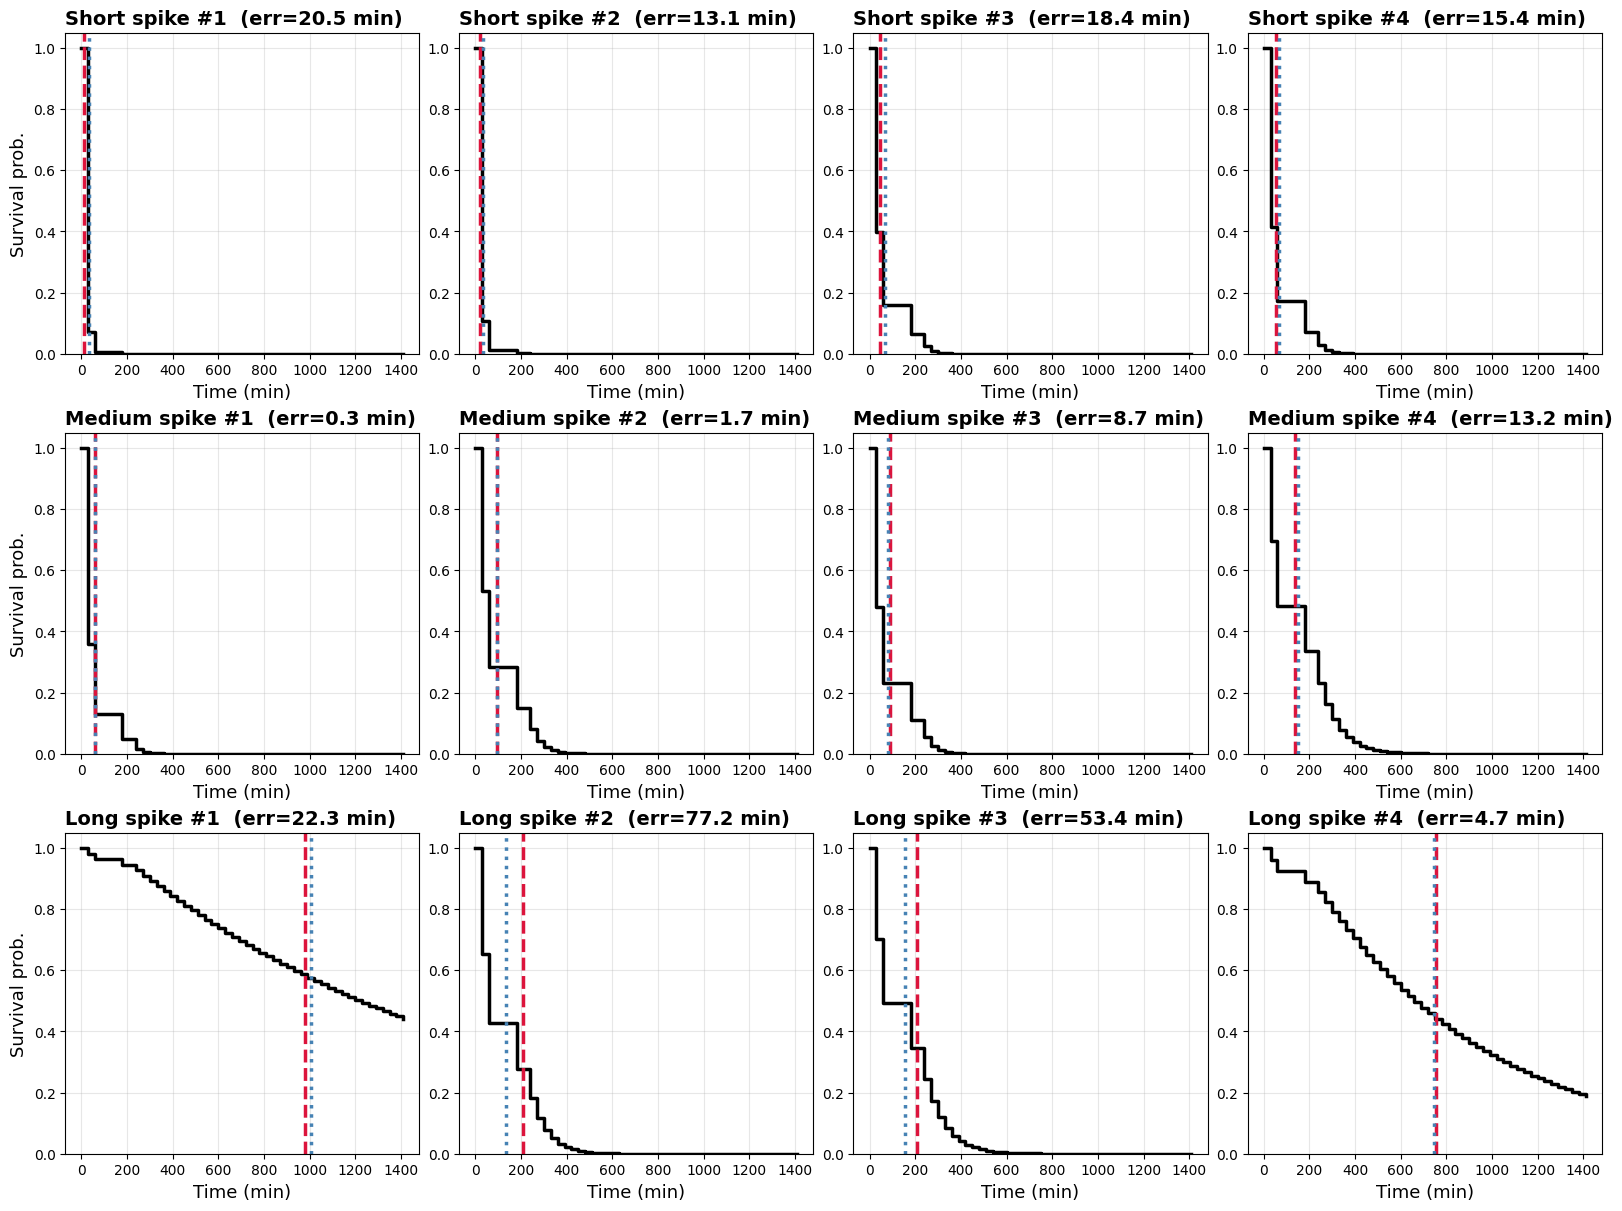

In [ ]:
def plot_survival_examples_paper(
    model,
    X_val,
    hazard_val,
    bins,
    n_examples_per_row=5,
    short_threshold=60,
    long_threshold=180,
    random_state=42,
    save_path=None,
):
    """
    Plot best-predicted survival curves for short, medium, and long spikes.

    For each duration category, picks the top 10 spikes with smallest absolute
    error between expected and true duration, then randomly selects `n_examples_per_row`
    to display. Produces a 3 x n_examples_per_row grid, publication‑ready styling.

    Parameters
    ----------
    model : fitted logistic regression model (predict_proba)
    X_val : DataFrame of validation features (aligned with hazard_val)
    hazard_val : DataFrame from prepare_hazard_dataset, must contain
                 spike_index, duration_minutes
    bins : array-like, bin boundaries (e.g., [0,30,120,360,1440])
    n_examples_per_row : int, columns per row (default 5)
    short_threshold : float, minutes; spikes ≤ this are 'Short'
    long_threshold : float, minutes; spikes > this are 'Long'
    random_state : int, for reproducible sampling
    save_path : str or None, if given saves the figure to this path
    """
    # Compute predictions and errors for all unique spikes
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()

    spike_errors = []
    for _, spike_row in unique_spikes.iterrows():
        spike_idx = spike_row['spike_index']
        true_duration = spike_row['duration_minutes']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_duration = predict_expected_duration(model, X_spike, bins)
        error = abs(true_duration - pred_duration)
        spike_errors.append({
            'spike_index': spike_idx,
            'duration_minutes': true_duration,
            'pred_duration': pred_duration,
            'abs_error': error,
        })

    errors_df = pd.DataFrame(spike_errors)

    # Categorise
    errors_df['category'] = 'Medium'
    errors_df.loc[errors_df['duration_minutes'] <= short_threshold, 'category'] = 'Short'
    errors_df.loc[errors_df['duration_minutes'] > long_threshold, 'category'] = 'Long'

    # Pick top-10 best in each category, then sample
    cnt=30
    best_short = errors_df[errors_df['category'] == 'Short'].nsmallest(cnt, 'abs_error')
    best_medium = errors_df[errors_df['category'] == 'Medium'].nsmallest(cnt, 'abs_error')
    best_long = errors_df[errors_df['category'] == 'Long'].nsmallest(cnt, 'abs_error')

    np.random.seed(random_state)
    sample_short = best_short.sample(n=min(n_examples_per_row, len(best_short)))
    sample_medium = best_medium.sample(n=min(n_examples_per_row, len(best_medium)))
    sample_long = best_long.sample(n=min(n_examples_per_row, len(best_long)))

    spike_groups = [sample_short, sample_medium, sample_long]
    row_labels = ['Short', 'Medium', 'Long']

    # Publication style
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 13,
        'legend.fontsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'lines.linewidth': 2,
    })

    fig, axes = plt.subplots(3, n_examples_per_row,
                             figsize=(4 * n_examples_per_row, 12),
                             constrained_layout=True)

    # Define colours and line styles
    color_surv = 'black'
    color_true = 'crimson'
    color_pred = 'steelblue'
    ls_true = '--'
    ls_pred = ':'
    lw_true = 2.5
    lw_pred = 2.5
    lw_surv = 2.5

    for row_idx, (sample, label) in enumerate(zip(spike_groups, row_labels)):
        n_sample = len(sample)
        for col_idx in range(n_examples_per_row):
            ax = axes[row_idx, col_idx]
            if col_idx >= n_sample:
                ax.set_visible(False)
                continue

            spike_row = sample.iloc[col_idx]
            spike_idx = spike_row['spike_index']
            true_duration = spike_row['duration_minutes']
            pred_duration = spike_row['pred_duration']
            error = spike_row['abs_error']

            mask = hazard_val['spike_index'] == spike_idx
            X_spike = X_val.loc[mask].iloc[[0]]
            times, surv = predict_survival_curve(model, X_spike, bins)

            # Plot survival curve
            ax.step(times, surv, where='post', color=color_surv, linewidth=lw_surv, label='Predicted survival')

            # Mark true and predicted durations
            ax.axvline(true_duration, color=color_true, linestyle=ls_true, linewidth=lw_true,
                       label=f'True: {true_duration:.0f} min')
            ax.axvline(pred_duration, color=color_pred, linestyle=ls_pred, linewidth=lw_pred,
                       label=f'Pred: {pred_duration:.0f} min')

            ax.set_xlabel('Time (min)')
            ax.set_ylabel('Survival prob.' if col_idx == 0 else '')
            ax.set_title(f'{label} spike #{col_idx+1}  (err={error:.1f} min)', loc='left', fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.05)

    # Single legend at the top of the figure
    handles, labels = axes[0, 0].get_legend_handles_labels()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()
    return fig


fig = plot_survival_examples_paper(
    model=model,
    X_val=X_val,
    hazard_val=hazard_val,
    bins=BINS_MINUTES,               # your bin array
    n_examples_per_row=4,            # or 3 or 5
    short_threshold=60,              # ≤60 min = Short
    long_threshold=180,              # >180 min = Long
    random_state=42,
    save_path='survival_curves_paper.pdf'
)


In [ ]:
df['spike_duration_seconds'].describe()

count    2.840500e+04
mean     2.434632e+05
std      2.361221e+05
min      0.000000e+00
25%      6.243600e+04
50%      1.509960e+05
75%      3.824880e+05
max      1.118772e+06
Name: spike_duration_seconds, dtype: float64

In [ ]:
hazard_df[hazard_df['spike_index'] == 2540]

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,duration_minutes,bin_start,bin_end,bin_label,event
11,eth_PT-reUSD-25JUN2026_usdc,2540,0.0,0.961259,0.961259,0.961259,0.195734,0.0,0.086472,1.282164e+07,13,0.440667,0.911434,0.322615,0.000000,0.001962,0.000787,0.915225,0.099344,2,109716.0,10104.0,10104,1.766019e+09,1.766019e+09,168.4,0,30,0-30m,0
12,eth_PT-reUSD-25JUN2026_usdc,2540,30.0,0.961259,0.961259,0.961259,0.195734,0.0,0.086472,1.282164e+07,13,0.440667,0.911434,0.322615,-0.000295,0.001919,0.001082,0.915225,0.099344,2,109716.0,8304.0,10104,1.766021e+09,1.766019e+09,168.4,30,60,30-60m,0
13,eth_PT-reUSD-25JUN2026_usdc,2540,60.0,0.961259,0.961259,0.961259,0.195734,0.0,0.086472,1.282164e+07,13,0.440667,0.911434,0.322615,-0.000295,0.001919,0.001082,0.915225,0.099344,2,109716.0,6504.0,10104,1.766023e+09,1.766019e+09,168.4,60,180,60-180m,1


In [ ]:
spikes_util_diffs = {}
fields_list = ['utilization_current', 'hhi', 'top3_share', 'top1_share', 'total_borrow_current']
for f in fields_list: spikes_util_diffs[f] = []
for i in hazard_df['spike_index'].unique():
    for field in fields_list:
        # print(hazard_df[hazard_df['spike_index'] == i].shape)
        lst = list(hazard_df[hazard_df['spike_index'] == i][field])[0]
        data = list(hazard_df[(hazard_df['spike_index'] == i) & (hazard_df['event'] == 0)][field] - lst)[1:]
        if len(data) == 0:
            continue
        spikes_util_diffs[field].append(np.mean(data))
        # print(spikes_util_diffs)


utilization_current
count    499.000000
mean      -0.011021
std        0.023022
min       -0.096623
25%       -0.015047
50%        0.000000
75%        0.000000
max        0.033820
dtype: float64


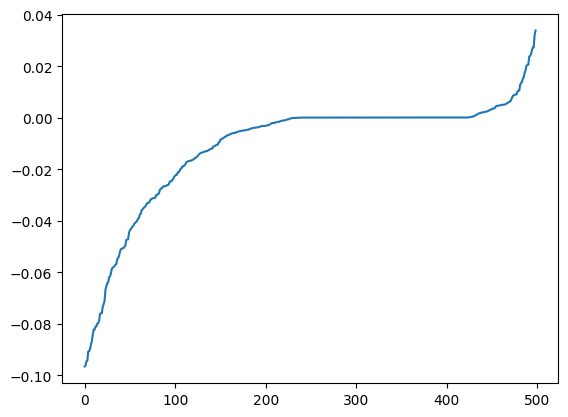

hhi
count    499.000000
mean       0.000136
std        0.008215
min       -0.098738
25%        0.000000
50%        0.000000
75%        0.000000
max        0.098670
dtype: float64


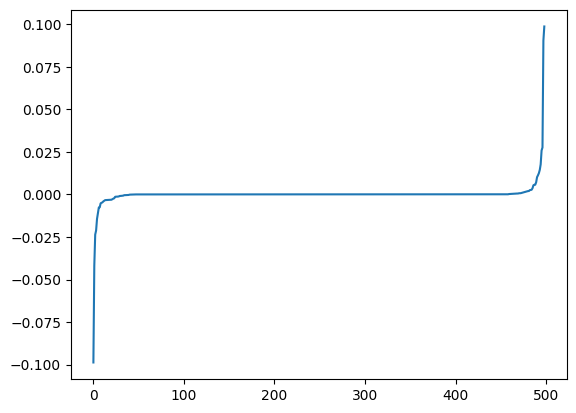

top3_share
count    499.000000
mean      -0.000407
std        0.007110
min       -0.114044
25%        0.000000
50%        0.000000
75%        0.000000
max        0.028968
dtype: float64


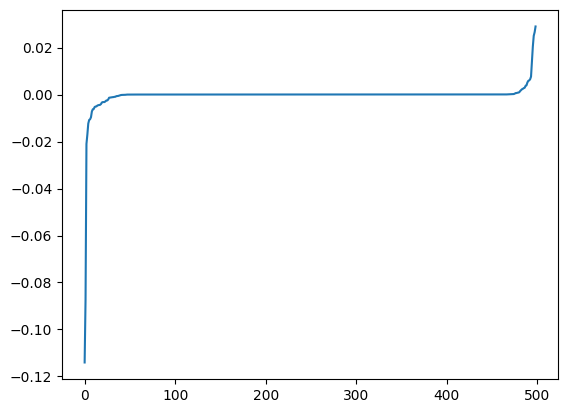

top1_share
count    499.000000
mean      -0.000056
std        0.011598
min       -0.164109
25%        0.000000
50%        0.000000
75%        0.000000
max        0.116392
dtype: float64


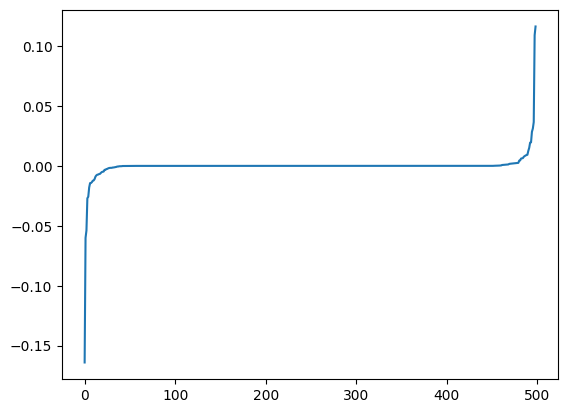

total_borrow_current
count    4.990000e+02
mean    -1.908458e+04
std      2.960393e+05
min     -2.831152e+06
25%      0.000000e+00
50%      7.108359e+00
75%      1.196789e+02
max      2.836898e+06
dtype: float64


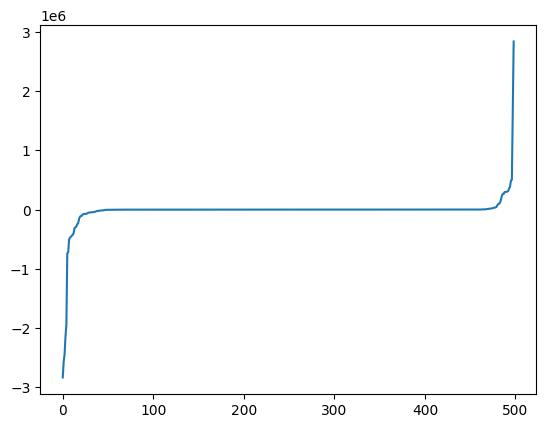

In [ ]:
for f in fields_list:
    print(f)
    print(pd.Series(spikes_util_diffs[f]).describe())
    pd.Series(sorted(spikes_util_diffs[f])).plot()
    plt.show()
